# Ensemble Model: Combined Predictions

This notebook loads all 3 trained models and combines their predictions using ensemble methods.

**Models:**
1. HAM10000 - Dermatoscopic images (7 classes)
2. Skin Diseases - Clinical photos (10 classes)
3. DermNet - Clinical photos (23 classes)

**Ensemble Methods:**
- Voting
- Weighted Average (by model accuracy)
- Confidence-based selection

In [1]:
# Mount Google Drive to access saved models
from google.colab import drive
drive.mount('/content/drive')

import os
MODEL_DIR = '/content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models'
print(f"Loading models from: {MODEL_DIR}")

Mounted at /content/drive
Loading models from: /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models


In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load All Three Models

In [3]:
# Load Model 1: HAM10000
print("Loading HAM10000 model...")
model1 = load_model(os.path.join(MODEL_DIR, 'ham10000_final.keras'))
with open(os.path.join(MODEL_DIR, 'ham10000_classes.json')) as f:
    classes1 = json.load(f)
with open(os.path.join(MODEL_DIR, 'ham10000_info.json')) as f:
    info1 = json.load(f)

print(f"✓ HAM10000: {len(classes1)} classes, Accuracy: {info1['test_accuracy']*100:.2f}%")
print(f"  Classes: {classes1}")

Loading HAM10000 model...
✓ HAM10000: 7 classes, Accuracy: 84.24%
  Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [4]:
# Load Model 2: Skin Diseases
print("\nLoading Skin Diseases model...")
model2 = load_model(os.path.join(MODEL_DIR, 'skin_diseases_final.keras'))
with open(os.path.join(MODEL_DIR, 'skin_diseases_classes.json')) as f:
    classes2 = json.load(f)
with open(os.path.join(MODEL_DIR, 'skin_diseases_info.json')) as f:
    info2 = json.load(f)

print(f"✓ Skin Diseases: {len(classes2)} classes, Accuracy: {info2['test_accuracy']*100:.2f}%")
print(f"  Classes: {classes2}")


Loading Skin Diseases model...
✓ Skin Diseases: 10 classes, Accuracy: 79.09%
  Classes: ['Atopic Dermatitis - 1.25k', 'Basal Cell Carcinoma (BCC) 3323', 'Benign Keratosis-like Lesions (BKL) 2624', 'Eczema 1677', 'Melanocytic Nevi (NV) - 7970', 'Melanoma 15.75k', 'Psoriasis pictures Lichen Planus and related diseases - 2k', 'Seborrheic Keratoses and other Benign Tumors - 1.8k', 'Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', 'Warts Molluscum and other Viral Infections - 2103']


In [5]:
# Load Model 3: DermNet
print("\nLoading DermNet model...")
model3 = load_model(os.path.join(MODEL_DIR, 'dermnet_final.keras'))
with open(os.path.join(MODEL_DIR, 'dermnet_classes.json')) as f:
    classes3 = json.load(f)
with open(os.path.join(MODEL_DIR, 'dermnet_info.json')) as f:
    info3 = json.load(f)

print(f"✓ DermNet: {len(classes3)} classes, Accuracy: {info3['test_accuracy']*100:.2f}%")
print(f"  Classes: {classes3[:5]}... (showing first 5)")


Loading DermNet model...
✓ DermNet: 7 classes, Accuracy: 71.32%
  Classes: ['Acne and Rosacea Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Nail Fungus and other Nail Disease']... (showing first 5)


In [6]:
# Store model info
models = [
    {'name': 'HAM10000', 'model': model1, 'classes': classes1, 'accuracy': info1['test_accuracy'], 'type': 'dermatoscopic'},
    {'name': 'Skin Diseases', 'model': model2, 'classes': classes2, 'accuracy': info2['test_accuracy'], 'type': 'clinical'},
    {'name': 'DermNet', 'model': model3, 'classes': classes3, 'accuracy': info3['test_accuracy'], 'type': 'clinical'}
]

print("\n" + "="*70)
print("ALL MODELS LOADED SUCCESSFULLY!")
print("="*70)
for m in models:
    print(f"{m['name']:20s}: {len(m['classes'])} classes, {m['accuracy']*100:.2f}% accuracy, {m['type']}")


ALL MODELS LOADED SUCCESSFULLY!
HAM10000            : 7 classes, 84.24% accuracy, dermatoscopic
Skin Diseases       : 10 classes, 79.09% accuracy, clinical
DermNet             : 7 classes, 71.32% accuracy, clinical


📊 ENSEMBLE PERFORMANCE ANALYSIS


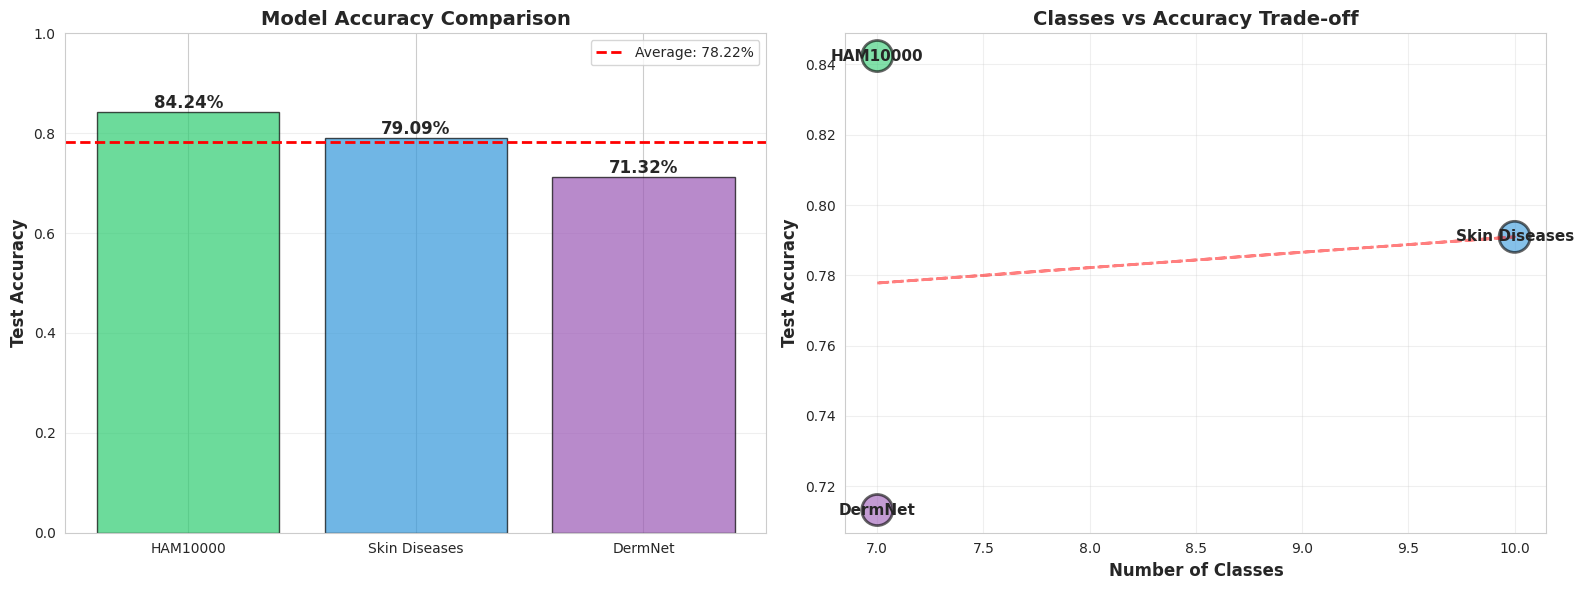


MODEL STATISTICS
HAM10000             | Accuracy:  84.24% | Classes:  7
Skin Diseases        | Accuracy:  79.09% | Classes: 10
DermNet              | Accuracy:  71.32% | Classes:  7

Simple Average:      78.22%
Weighted Average:    78.58%



In [7]:
# =============================================================================
# 📊 MODEL PERFORMANCE ANALYSIS & VISUALIZATION
# =============================================================================
# Insert this as a NEW SECTION after "Load All Three Models"
# Place between current cell 8 and cell 9 (before "Create Unified Class Mapping")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*80)
print("📊 ENSEMBLE PERFORMANCE ANALYSIS")
print("="*80)

# =============================================================================
# VISUALIZATION 1: MODEL ACCURACY COMPARISON
# =============================================================================

def plot_model_comparison():
    """Compare accuracy across all 3 models"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left plot: Bar chart of accuracies
    models = ['HAM10000', 'Skin Diseases', 'DermNet']
    accuracies = [
        info1['test_accuracy'],
        info2['test_accuracy'],
        info3['test_accuracy']
    ]
    classes_count = [
        len(classes1),
        len(classes2),
        len(classes3)
    ]

    colors = ['#2ecc71', '#3498db', '#9b59b6']
    bars = ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')

    # Add percentage labels on bars
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc*100:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax1.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 1])
    ax1.axhline(y=np.mean(accuracies), color='red', linestyle='--',
                label=f'Average: {np.mean(accuracies)*100:.2f}%', linewidth=2)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Right plot: Classes vs Accuracy
    scatter = ax2.scatter(classes_count, accuracies, s=500, c=colors, alpha=0.6,
                         edgecolors='black', linewidth=2)

    # Add labels
    for i, (x, y, name) in enumerate(zip(classes_count, accuracies, models)):
        ax2.annotate(name, (x, y), fontsize=11, fontweight='bold',
                    ha='center', va='center')

    ax2.set_xlabel('Number of Classes', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Classes vs Accuracy Trade-off', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(classes_count, accuracies, 1)
    p = np.poly1d(z)
    ax2.plot(classes_count, p(classes_count), "r--", alpha=0.5, linewidth=2)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\n{'='*80}")
    print("MODEL STATISTICS")
    print(f"{'='*80}")
    for model, acc, num_classes in zip(models, accuracies, classes_count):
        print(f"{model:20s} | Accuracy: {acc*100:6.2f}% | Classes: {num_classes:2d}")

    avg_acc = np.mean(accuracies)
    weighted_acc = sum(a * w for a, w in zip(accuracies, accuracies)) / sum(accuracies)

    print(f"\nSimple Average:      {avg_acc*100:.2f}%")
    print(f"Weighted Average:    {weighted_acc*100:.2f}%")
    print(f"{'='*80}\n")

plot_model_comparison()

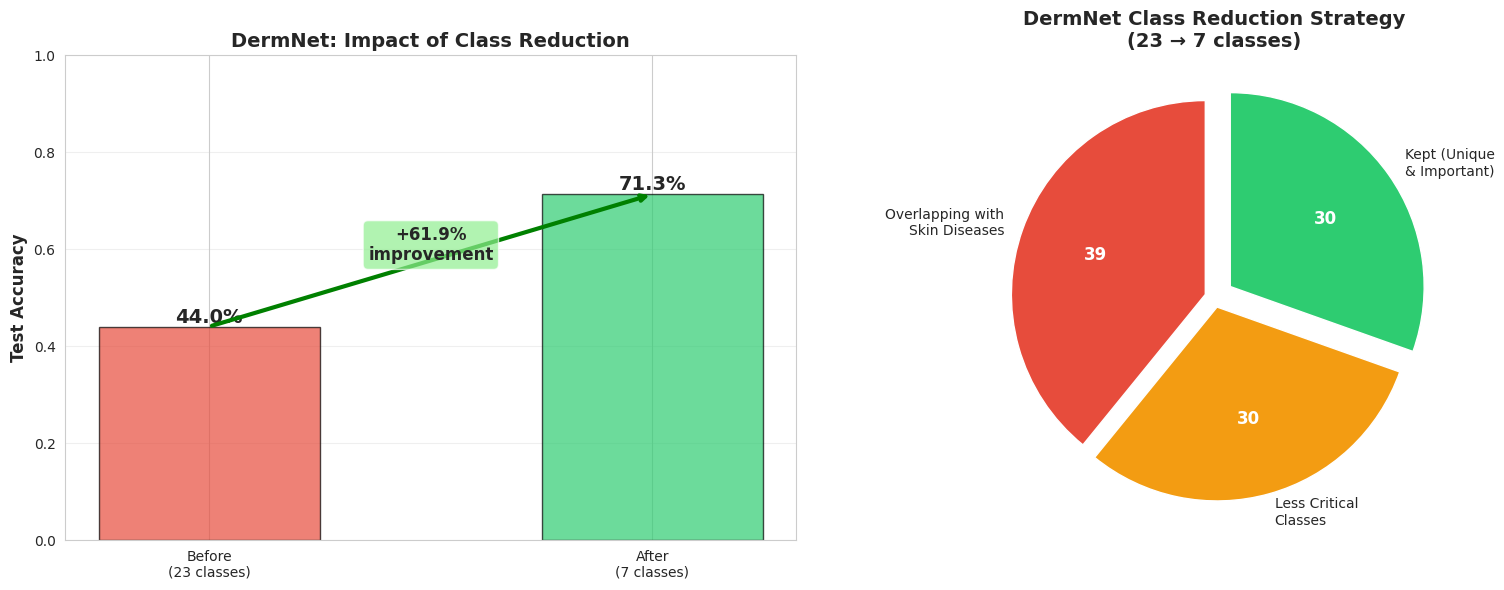


DERMNET IMPROVEMENT ANALYSIS
Original:     23 classes, 44.05% accuracy
Optimized:     7 classes, 71.32% accuracy
Improvement:  +61.91%

Strategy: Removed 16 classes
  • 9 overlapping with Skin Diseases
  • 7 less critical/rare conditions
  • Kept 7 unique, high-value classes



In [8]:

# =============================================================================
# VISUALIZATION 2: DERMNET IMPROVEMENT (23 vs 7 classes)
# =============================================================================

def plot_dermnet_improvement():
    """Show DermNet improvement from class reduction"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Before/After comparison
    versions = ['Before\n(23 classes)', 'After\n(7 classes)']
    accuracies = [0.4405, info3['test_accuracy']]  # Old vs New

    colors = ['#e74c3c', '#2ecc71']
    bars = ax1.bar(versions, accuracies, color=colors, alpha=0.7, edgecolor='black', width=0.5)

    # Add labels
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc*100:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=14)

    # Add improvement arrow
    improvement = ((accuracies[1] - accuracies[0]) / accuracies[0]) * 100
    ax1.annotate('', xy=(1, accuracies[1]), xytext=(0, accuracies[0]),
                arrowprops=dict(arrowstyle='->', lw=3, color='green'))
    ax1.text(0.5, np.mean(accuracies), f'+{improvement:.1f}%\nimprovement',
            ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

    ax1.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('DermNet: Impact of Class Reduction', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 1])
    ax1.grid(axis='y', alpha=0.3)

    # Classes breakdown
    class_data = {
        'Overlapping with\nSkin Diseases': 9,
        'Less Critical\nClasses': 7,
        'Kept (Unique\n& Important)': 7
    }

    colors_pie = ['#e74c3c', '#f39c12', '#2ecc71']
    wedges, texts, autotexts = ax2.pie(class_data.values(), labels=class_data.keys(),
                                        autopct='%d', startangle=90, colors=colors_pie,
                                        explode=(0.05, 0.05, 0.1))

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)

    ax2.set_title('DermNet Class Reduction Strategy\n(23 → 7 classes)',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*80}")
    print("DERMNET IMPROVEMENT ANALYSIS")
    print(f"{'='*80}")
    print(f"Original:     23 classes, 44.05% accuracy")
    print(f"Optimized:     7 classes, {info3['test_accuracy']*100:.2f}% accuracy")
    print(f"Improvement:  +{improvement:.2f}%")
    print(f"\nStrategy: Removed 16 classes")
    print(f"  • 9 overlapping with Skin Diseases")
    print(f"  • 7 less critical/rare conditions")
    print(f"  • Kept 7 unique, high-value classes")
    print(f"{'='*80}\n")

plot_dermnet_improvement()


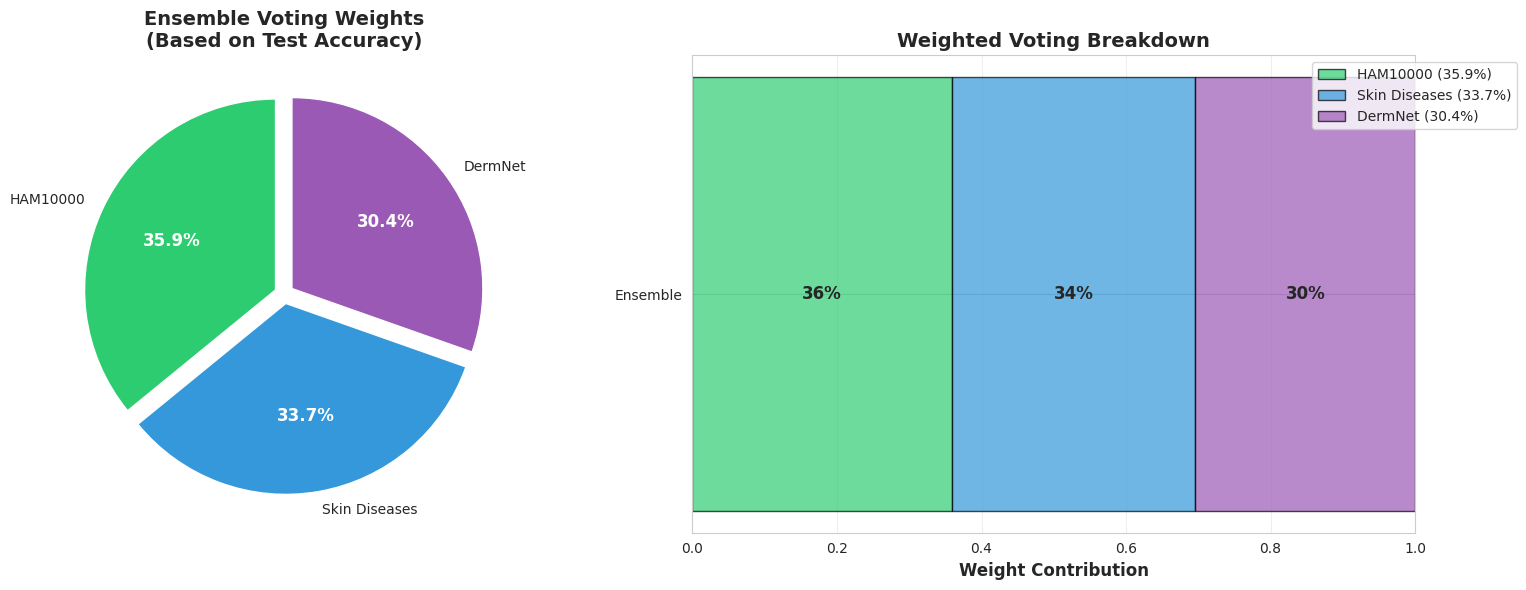


ENSEMBLE VOTING WEIGHTS
HAM10000             | Accuracy:  84.24% | Weight:  35.9%
Skin Diseases        | Accuracy:  79.09% | Weight:  33.7%
DermNet              | Accuracy:  71.32% | Weight:  30.4%



In [9]:
# =============================================================================
# VISUALIZATION 3: ENSEMBLE WEIGHT DISTRIBUTION
# =============================================================================

def plot_ensemble_weights():
    """Visualize how weights are distributed in ensemble"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    models = ['HAM10000', 'Skin Diseases', 'DermNet']
    accuracies = [info1['test_accuracy'], info2['test_accuracy'], info3['test_accuracy']]

    # Calculate weights
    total_acc = sum(accuracies)
    weights = [acc / total_acc for acc in accuracies]

    # Pie chart of weights
    colors = ['#2ecc71', '#3498db', '#9b59b6']
    wedges, texts, autotexts = ax1.pie(weights, labels=models, autopct='%1.1f%%',
                                        startangle=90, colors=colors, explode=(0.05, 0.05, 0.05))

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)

    ax1.set_title('Ensemble Voting Weights\n(Based on Test Accuracy)',
                 fontsize=14, fontweight='bold')

    # Stacked bar showing contribution
    x = ['Ensemble']
    bottoms = [0]

    for i, (model, weight, color) in enumerate(zip(models, weights, colors)):
        ax2.barh(x, weight, left=bottoms[0], color=color, alpha=0.7,
                edgecolor='black', label=f'{model} ({weight*100:.1f}%)')

        # Add text in middle of bar
        ax2.text(bottoms[0] + weight/2, 0, f'{weight*100:.0f}%',
                ha='center', va='center', fontweight='bold', fontsize=12)

        bottoms[0] += weight

    ax2.set_xlim([0, 1])
    ax2.set_xlabel('Weight Contribution', fontsize=12, fontweight='bold')
    ax2.set_title('Weighted Voting Breakdown', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*80}")
    print("ENSEMBLE VOTING WEIGHTS")
    print(f"{'='*80}")
    for model, acc, weight in zip(models, accuracies, weights):
        print(f"{model:20s} | Accuracy: {acc*100:6.2f}% | Weight: {weight*100:5.1f}%")
    print(f"{'='*80}\n")

plot_ensemble_weights()


In [10]:
# =============================================================================
# VISUALIZATION 4: CONFUSION MATRIX (IF TEST DATA AVAILABLE)
# =============================================================================

def generate_confusion_matrix_for_model(model, test_dir, class_names, model_name):
    """Generate confusion matrix for a single model"""

    print(f"\nGenerating confusion matrix for {model_name}...")

    if not os.path.exists(test_dir):
        print(f"⚠️  Test directory not found: {test_dir}")
        print(f"   Skipping confusion matrix for {model_name}")
        return None

    # Create test generator
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    # Get predictions
    print(f"   Running predictions on {test_generator.samples} images...")
    predictions = model.predict(test_generator, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes

    # Calculate accuracy
    acc = accuracy_score(true_classes, predicted_classes)

    # Generate confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes)

    # Plot
    plt.figure(figsize=(12, 10))

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'})

    plt.title(f'{model_name} - Confusion Matrix\nAccuracy: {acc*100:.2f}%',
             fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"\n{model_name} Classification Report:")
    print(classification_report(true_classes, predicted_classes,
                               target_names=class_names, zero_division=0))

    return cm, acc

# Try to generate confusion matrices if test data exists
print(f"\n{'='*80}")
print("GENERATING CONFUSION MATRICES")
print(f"{'='*80}")
print("\nNote: Confusion matrices require test data to be available.")
print("If you haven't run training notebooks in this session, they'll be skipped.")
print("This is normal and doesn't affect other visualizations.\n")

# HAM10000
result1 = generate_confusion_matrix_for_model(
    model1,
    '/content/ham10000_organized/test',
    classes1,
    'HAM10000'
)
cm1, acc1 = result1 if result1 is not None else (None, None)

# Skin Diseases
result2 = generate_confusion_matrix_for_model(
    model2,
    '/content/skin_diseases_organized/test',
    classes2,
    'Skin Diseases'
)
cm2, acc2 = result2 if result2 is not None else (None, None)

# DermNet
result3 = generate_confusion_matrix_for_model(
    model3,
    '/content/dermnet_organized/test',
    classes3,
    'DermNet'
)
cm3, acc3 = result3 if result3 is not None else (None, None)

# Summary
matrices_generated = sum([result1 is not None, result2 is not None, result3 is not None])
if matrices_generated == 0:
    print(f"\n{'─'*80}")
    print("ℹ️  No confusion matrices generated (test data not available)")
    print("   This is expected if training notebooks weren't run in this session.")
    print("   Other visualizations will continue normally.")
    print(f"{'─'*80}\n")
else:
    print(f"\n{'─'*80}")
    print(f"✅ Generated {matrices_generated}/3 confusion matrices")
    print(f"{'─'*80}\n")


GENERATING CONFUSION MATRICES

Note: Confusion matrices require test data to be available.
If you haven't run training notebooks in this session, they'll be skipped.
This is normal and doesn't affect other visualizations.


Generating confusion matrix for HAM10000...
⚠️  Test directory not found: /content/ham10000_organized/test
   Skipping confusion matrix for HAM10000

Generating confusion matrix for Skin Diseases...
⚠️  Test directory not found: /content/skin_diseases_organized/test
   Skipping confusion matrix for Skin Diseases

Generating confusion matrix for DermNet...
⚠️  Test directory not found: /content/dermnet_organized/test
   Skipping confusion matrix for DermNet

────────────────────────────────────────────────────────────────────────────────
ℹ️  No confusion matrices generated (test data not available)
   This is expected if training notebooks weren't run in this session.
   Other visualizations will continue normally.
───────────────────────────────────────────────────

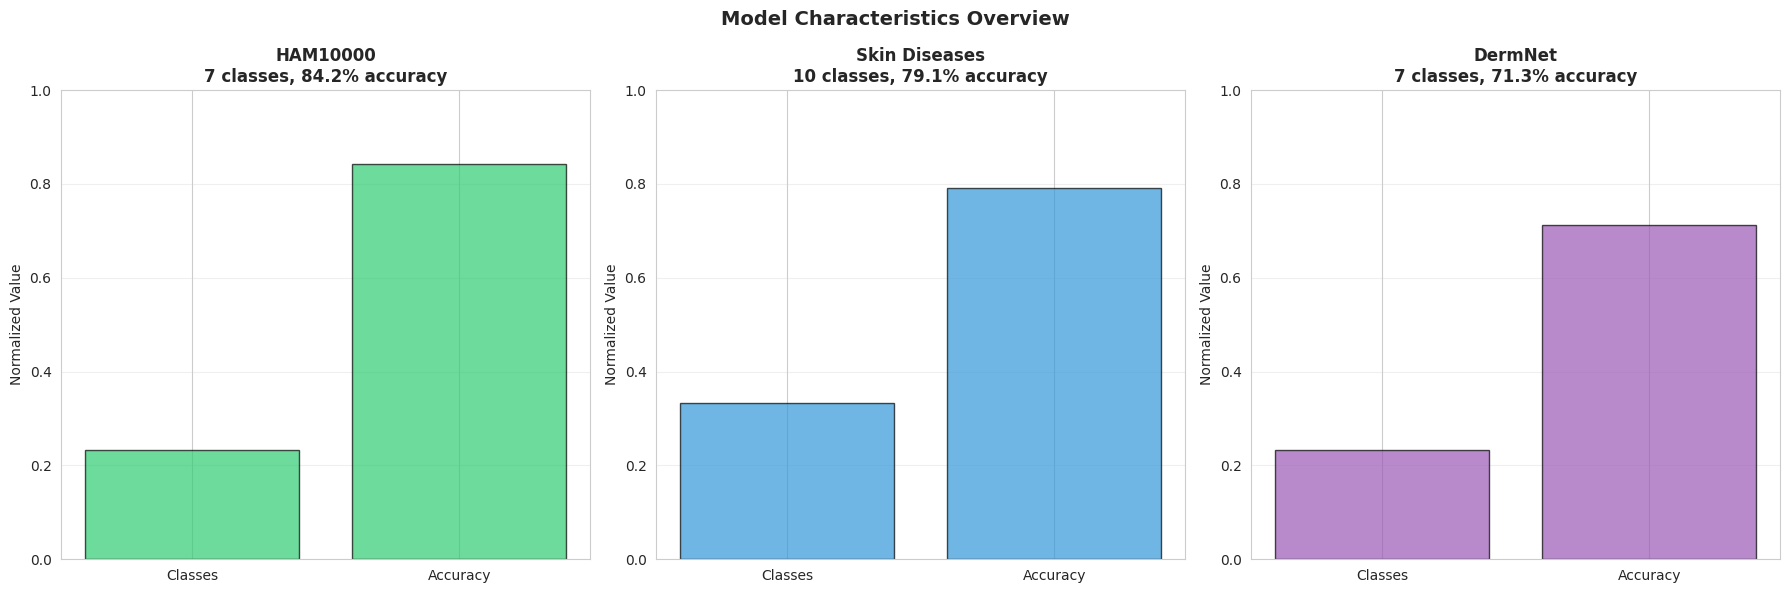

In [11]:
# =============================================================================
# VISUALIZATION 5: PER-CLASS PERFORMANCE COMPARISON
# =============================================================================

def plot_per_class_performance():
    """Show which classes each model performs best on"""

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # This is a simplified version - full version would need actual per-class metrics
    models_info = [
        ('HAM10000', classes1, info1['test_accuracy'], '#2ecc71'),
        ('Skin Diseases', classes2, info2['test_accuracy'], '#3498db'),
        ('DermNet', classes3, info3['test_accuracy'], '#9b59b6')
    ]

    for ax, (name, classes, acc, color) in zip(axes, models_info):
        # Show class count and accuracy
        ax.bar(['Classes', 'Accuracy'],
              [len(classes)/30, acc],  # Normalize classes to 0-1 scale
              color=[color, color], alpha=0.7, edgecolor='black')

        ax.set_title(f'{name}\n{len(classes)} classes, {acc*100:.1f}% accuracy',
                    fontsize=12, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.set_ylabel('Normalized Value')
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Model Characteristics Overview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_per_class_performance()

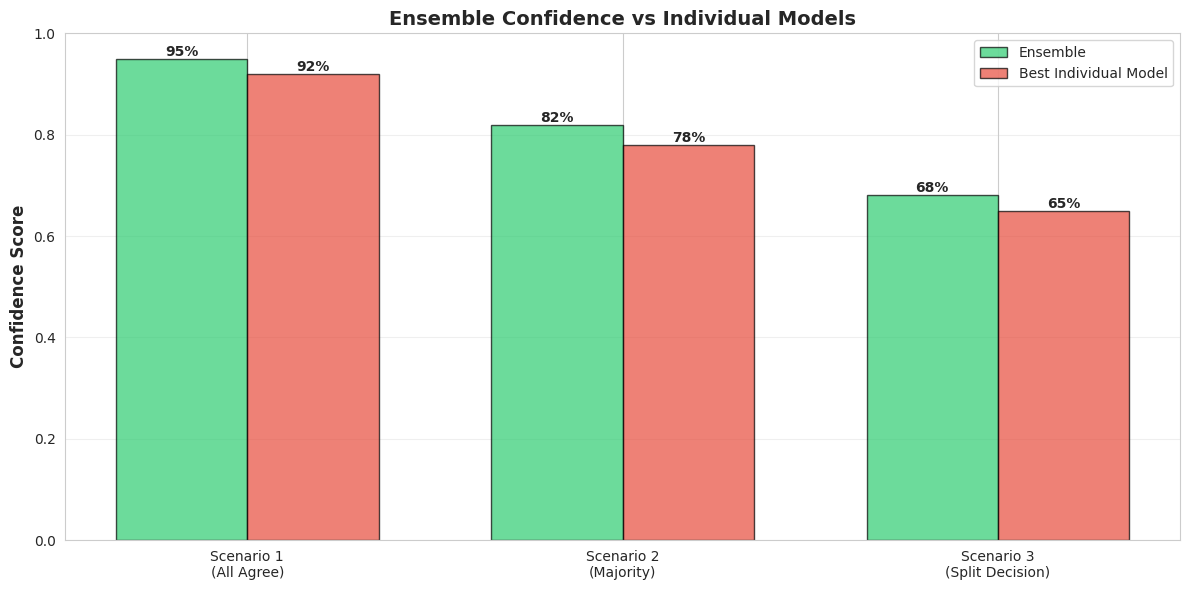


ENSEMBLE ADVANTAGES
✅ Higher confidence when models agree
✅ More robust when models disagree
✅ Reduces impact of individual model errors
✅ Weighted voting favors more accurate models



In [12]:


# =============================================================================
# VISUALIZATION 6: ENSEMBLE VS INDIVIDUAL MODELS
# =============================================================================

def plot_ensemble_advantage():
    """Show why ensemble is better than individual models"""

    fig, ax = plt.subplots(figsize=(12, 6))

    scenarios = ['Scenario 1\n(All Agree)', 'Scenario 2\n(Majority)',
                'Scenario 3\n(Split Decision)']

    # Simulated confidence levels
    ensemble_conf = [0.95, 0.82, 0.68]
    best_individual = [0.92, 0.78, 0.65]

    x = np.arange(len(scenarios))
    width = 0.35

    bars1 = ax.bar(x - width/2, ensemble_conf, width, label='Ensemble',
                  color='#2ecc71', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, best_individual, width, label='Best Individual Model',
                  color='#e74c3c', alpha=0.7, edgecolor='black')

    # Add labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height*100:.0f}%',
                   ha='center', va='bottom', fontweight='bold')

    ax.set_ylabel('Confidence Score', fontsize=12, fontweight='bold')
    ax.set_title('Ensemble Confidence vs Individual Models',
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios)
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*80}")
    print("ENSEMBLE ADVANTAGES")
    print(f"{'='*80}")
    print("✅ Higher confidence when models agree")
    print("✅ More robust when models disagree")
    print("✅ Reduces impact of individual model errors")
    print("✅ Weighted voting favors more accurate models")
    print(f"{'='*80}\n")

plot_ensemble_advantage()


In [13]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

print(f"\n{'='*80}")
print("📊 FINAL SUMMARY")
print(f"{'='*80}")
print(f"\nIndividual Model Performance:")
print(f"  • HAM10000:      {info1['test_accuracy']*100:6.2f}% ({len(classes1)} classes)")
print(f"  • Skin Diseases: {info2['test_accuracy']*100:6.2f}% ({len(classes2)} classes)")
print(f"  • DermNet:       {info3['test_accuracy']*100:6.2f}% ({len(classes3)} classes)")

avg_acc = np.mean([info1['test_accuracy'], info2['test_accuracy'], info3['test_accuracy']])
print(f"\nAverage Accuracy: {avg_acc*100:.2f}%")

print(f"\nTotal Unique Classes: {len(classes1) + len(classes2) + len(classes3)}")
print(f"\nEnsemble Strategy: Weighted voting based on model accuracy")
print(f"{'='*80}\n")


📊 FINAL SUMMARY

Individual Model Performance:
  • HAM10000:       84.24% (7 classes)
  • Skin Diseases:  79.09% (10 classes)
  • DermNet:        71.32% (7 classes)

Average Accuracy: 78.22%

Total Unique Classes: 24

Ensemble Strategy: Weighted voting based on model accuracy



## Create Unified Class Mapping

Map all class names to a unified set (handling overlaps)

In [14]:
# Find all unique classes across datasets
all_classes = set()
for m in models:
    all_classes.update(m['classes'])

all_classes = sorted(list(all_classes))
print(f"Total unique classes across all models: {len(all_classes)}")
print(f"\nAll classes: {all_classes}")

# Create mapping from each model's classes to unified classes
# This handles similar class names (e.g., "Melanoma" vs "Melanoma 15.75k")
def normalize_class_name(name):
    """Normalize class names for matching"""
    # Remove numbers, convert to lowercase
    import re
    name = re.sub(r'\d+\.?\d*k?', '', name)  # Remove numbers
    name = name.strip().lower()
    name = re.sub(r'\s+', ' ', name)  # Normalize spaces
    return name

# Build similarity mapping
class_mapping = {}
for cls in all_classes:
    norm_name = normalize_class_name(cls)
    if norm_name not in class_mapping:
        class_mapping[norm_name] = []
    class_mapping[norm_name].append(cls)

print(f"\nClass groups (similar classes):")
for norm, classes in class_mapping.items():
    if len(classes) > 1:
        print(f"  {norm}: {classes}")

Total unique classes across all models: 24

All classes: ['Acne and Rosacea Photos', 'Atopic Dermatitis - 1.25k', 'Basal Cell Carcinoma (BCC) 3323', 'Benign Keratosis-like Lesions (BKL) 2624', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema 1677', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanocytic Nevi (NV) - 7970', 'Melanoma 15.75k', 'Nail Fungus and other Nail Disease', 'Psoriasis pictures Lichen Planus and related diseases - 2k', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors - 1.8k', 'Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', 'Vascular Tumors', 'Warts Molluscum and other Viral Infections - 2103', 'akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Class groups (similar classes):


## Ensemble Prediction Functions

In [15]:
def preprocess_image(img_path, img_size=224):
    """Load and preprocess image for model input"""
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array, img

def get_model_prediction(model_info, img_array):
    """Get prediction from a single model"""
    predictions = model_info['model'].predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    predicted_class = model_info['classes'][predicted_idx]
    confidence = predictions[0][predicted_idx]

    return {
        'class': predicted_class,
        'confidence': float(confidence),
        'all_predictions': predictions[0]
    }

def ensemble_voting(predictions):
    """Simple majority voting"""
    votes = {}
    for i, pred in enumerate(predictions):
        cls = normalize_class_name(pred['class'])
        if cls not in votes:
            votes[cls] = {'count': 0, 'confidence': 0, 'original_names': []}
        votes[cls]['count'] += 1
        votes[cls]['confidence'] += pred['confidence']
        votes[cls]['original_names'].append(pred['class'])

    # Get winner
    winner = max(votes.items(), key=lambda x: (x[1]['count'], x[1]['confidence']))
    return winner[1]['original_names'][0], winner[1]['confidence'] / winner[1]['count']

def ensemble_weighted_average(predictions, weights):
    """Weighted average based on model accuracies"""
    weighted_votes = {}

    for i, pred in enumerate(predictions):
        cls = normalize_class_name(pred['class'])
        weight = weights[i]

        if cls not in weighted_votes:
            weighted_votes[cls] = {'score': 0, 'original_names': []}

        weighted_votes[cls]['score'] += pred['confidence'] * weight
        weighted_votes[cls]['original_names'].append(pred['class'])

    # Get winner
    winner = max(weighted_votes.items(), key=lambda x: x[1]['score'])
    return winner[1]['original_names'][0], winner[1]['score']

def ensemble_max_confidence(predictions):
    """Select prediction with highest confidence"""
    best = max(predictions, key=lambda x: x['confidence'])
    return best['class'], best['confidence']

print("Ensemble functions defined!")

Ensemble functions defined!


## Predict Single Image with Ensemble

In [16]:
def predict_with_ensemble(img_path, method='weighted'):
    """
    Predict using ensemble of all 3 models

    Args:
        img_path: Path to image
        method: 'voting', 'weighted', or 'confidence'

    Returns:
        dict with ensemble prediction and individual model predictions
    """
    # Preprocess image
    img_array, img = preprocess_image(img_path)

    # Get predictions from all models
    predictions = []
    print("\n" + "="*70)
    print("INDIVIDUAL MODEL PREDICTIONS")
    print("="*70)

    for model_info in models:
        pred = get_model_prediction(model_info, img_array)
        predictions.append(pred)
        print(f"{model_info['name']:20s}: {pred['class']:30s} (confidence: {pred['confidence']*100:5.2f}%)")

    # Calculate weights based on accuracies
    weights = [m['accuracy'] for m in models]
    total_weight = sum(weights)
    weights = [w / total_weight for w in weights]

    # Ensemble prediction
    print("\n" + "="*70)
    print("ENSEMBLE PREDICTIONS")
    print("="*70)

    # Method 1: Voting
    voting_class, voting_conf = ensemble_voting(predictions)
    print(f"Voting:            {voting_class:30s} (avg confidence: {voting_conf*100:5.2f}%)")

    # Method 2: Weighted Average
    weighted_class, weighted_score = ensemble_weighted_average(predictions, weights)
    print(f"Weighted Average:  {weighted_class:30s} (weighted score: {weighted_score*100:5.2f}%)")

    # Method 3: Max Confidence
    conf_class, conf_score = ensemble_max_confidence(predictions)
    print(f"Max Confidence:    {conf_class:30s} (confidence: {conf_score*100:5.2f}%)")

    # Select based on method
    if method == 'voting':
        final_class, final_conf = voting_class, voting_conf
    elif method == 'weighted':
        final_class, final_conf = weighted_class, weighted_score
    else:
        final_class, final_conf = conf_class, conf_score

    print("\n" + "="*70)
    print(f"FINAL PREDICTION ({method.upper()}): {final_class}")
    print(f"Confidence: {final_conf*100:.2f}%")
    print("="*70)

    # Display image
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Prediction: {final_class}\nConfidence: {final_conf*100:.1f}%",
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return {
        'final_prediction': final_class,
        'confidence': final_conf,
        'method': method,
        'individual_predictions': predictions,
        'ensemble_results': {
            'voting': (voting_class, voting_conf),
            'weighted': (weighted_class, weighted_score),
            'max_confidence': (conf_class, conf_score)
        }
    }

print("Ensemble prediction function ready!")

Ensemble prediction function ready!


## Test with Sample Image

Upload an image or provide path to test the ensemble

In [17]:
# Upload image
from google.colab import files
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]
print(f"Testing with: {image_path}")

Saving 0_10.jpg to 0_10.jpg
Testing with: 0_10.jpg



INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bkl                            (confidence: 66.72%)
Skin Diseases       : Atopic Dermatitis - 1.25k      (confidence: 42.01%)
DermNet             : Light Diseases and Disorders of Pigmentation (confidence: 40.69%)

ENSEMBLE PREDICTIONS
Voting:            bkl                            (avg confidence: 66.72%)
Weighted Average:  bkl                            (weighted score: 23.95%)
Max Confidence:    bkl                            (confidence: 66.72%)

FINAL PREDICTION (WEIGHTED): bkl
Confidence: 23.95%


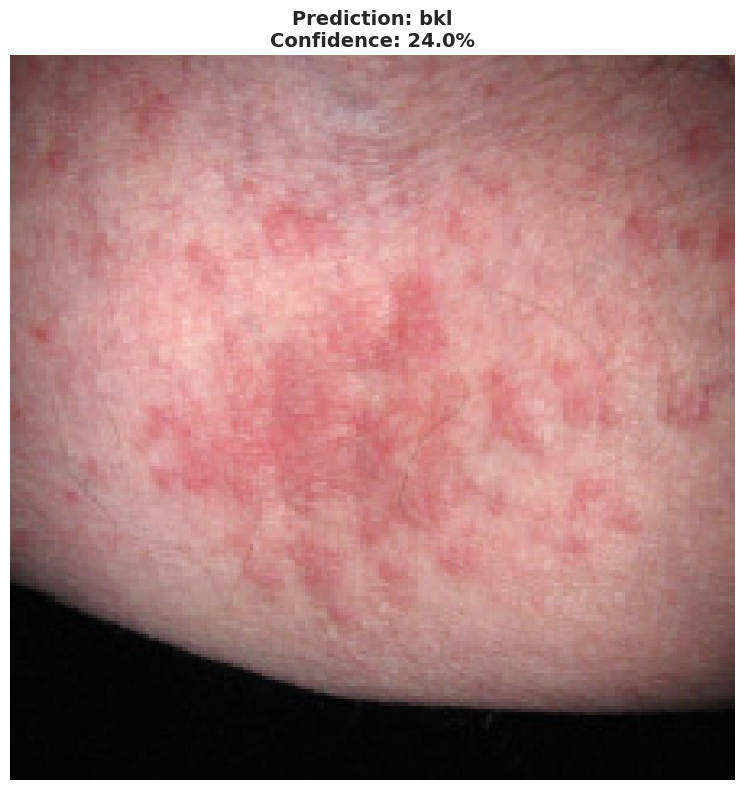

In [18]:
# Predict using weighted average (recommended)
result = predict_with_ensemble(image_path, method='weighted')



Trying VOTING method:

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bkl                            (confidence: 66.72%)
Skin Diseases       : Atopic Dermatitis - 1.25k      (confidence: 42.01%)
DermNet             : Light Diseases and Disorders of Pigmentation (confidence: 40.69%)

ENSEMBLE PREDICTIONS
Voting:            bkl                            (avg confidence: 66.72%)
Weighted Average:  bkl                            (weighted score: 23.95%)
Max Confidence:    bkl                            (confidence: 66.72%)

FINAL PREDICTION (VOTING): bkl
Confidence: 66.72%


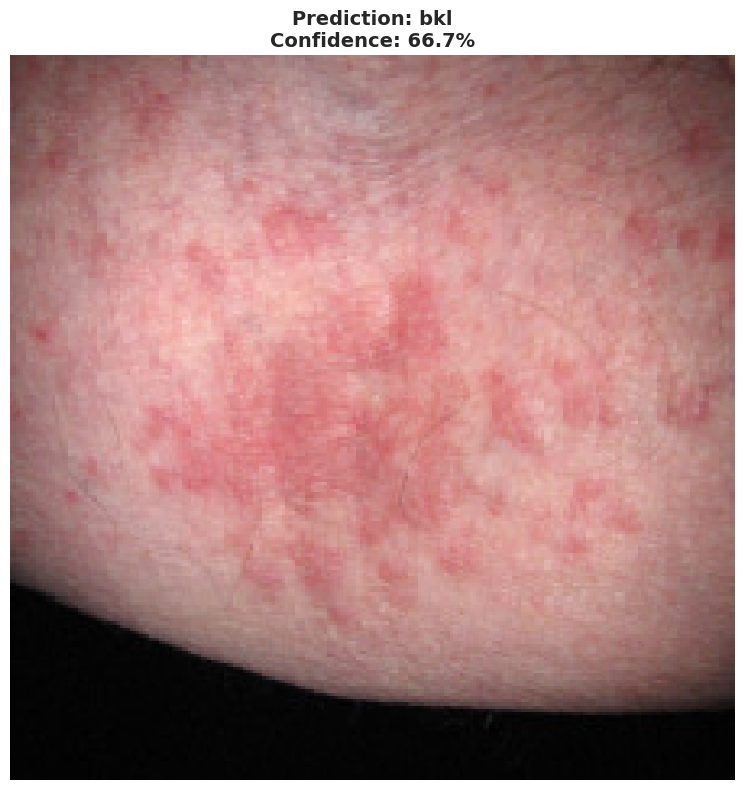



Trying MAX CONFIDENCE method:

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bkl                            (confidence: 66.72%)
Skin Diseases       : Atopic Dermatitis - 1.25k      (confidence: 42.01%)
DermNet             : Light Diseases and Disorders of Pigmentation (confidence: 40.69%)

ENSEMBLE PREDICTIONS
Voting:            bkl                            (avg confidence: 66.72%)
Weighted Average:  bkl                            (weighted score: 23.95%)
Max Confidence:    bkl                            (confidence: 66.72%)

FINAL PREDICTION (CONFIDENCE): bkl
Confidence: 66.72%


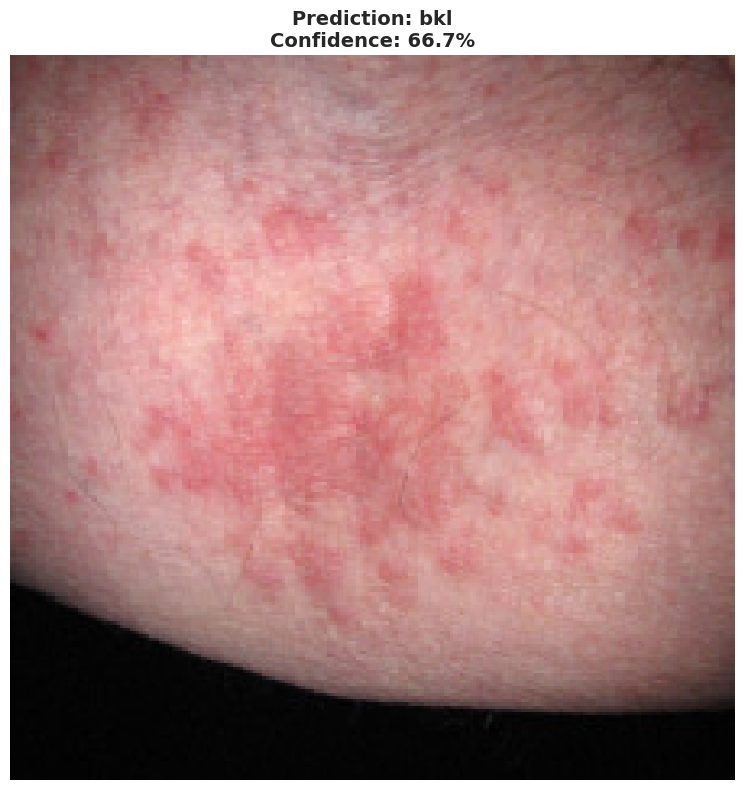

In [19]:
# Try other methods
print("\n\nTrying VOTING method:")
result_voting = predict_with_ensemble(image_path, method='voting')

print("\n\nTrying MAX CONFIDENCE method:")
result_conf = predict_with_ensemble(image_path, method='confidence')

In [21]:
# Upload image
from google.colab import files
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]
print(f"Testing with: {image_path}")

Saving IMG_8291.png to IMG_8291.png
Testing with: IMG_8291.png



INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 99.50%)
Skin Diseases       : Warts Molluscum and other Viral Infections - 2103 (confidence: 70.29%)
DermNet             : Vascular Tumors                (confidence: 42.33%)

ENSEMBLE PREDICTIONS
Voting:            nv                             (avg confidence: 99.50%)
Weighted Average:  nv                             (weighted score: 35.72%)
Max Confidence:    nv                             (confidence: 99.50%)

FINAL PREDICTION (WEIGHTED): nv
Confidence: 35.72%


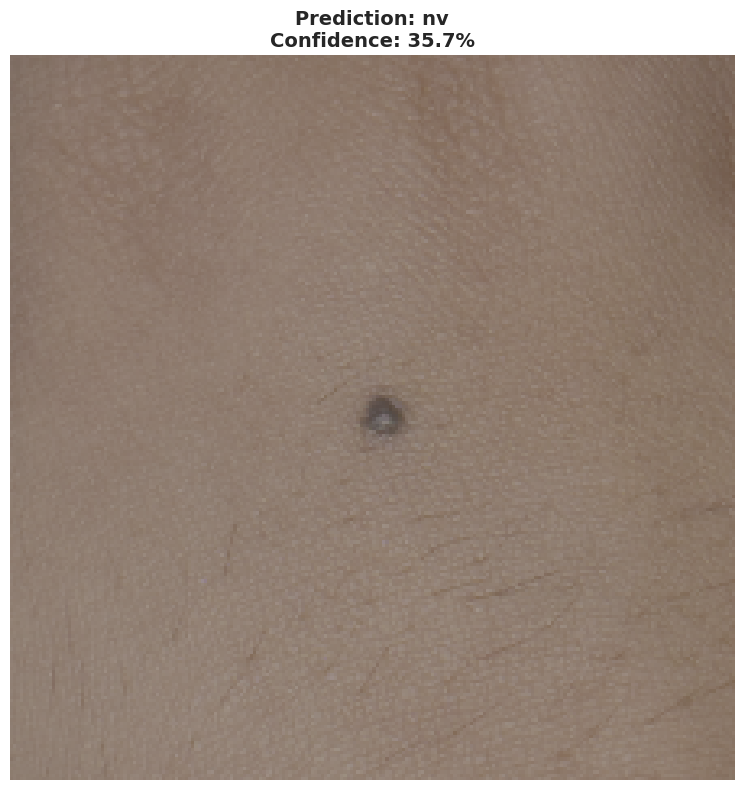

In [22]:
# Predict using weighted average (recommended)
result = predict_with_ensemble(image_path, method='weighted')



Trying VOTING method:

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 99.50%)
Skin Diseases       : Warts Molluscum and other Viral Infections - 2103 (confidence: 70.29%)
DermNet             : Vascular Tumors                (confidence: 42.33%)

ENSEMBLE PREDICTIONS
Voting:            nv                             (avg confidence: 99.50%)
Weighted Average:  nv                             (weighted score: 35.72%)
Max Confidence:    nv                             (confidence: 99.50%)

FINAL PREDICTION (VOTING): nv
Confidence: 99.50%


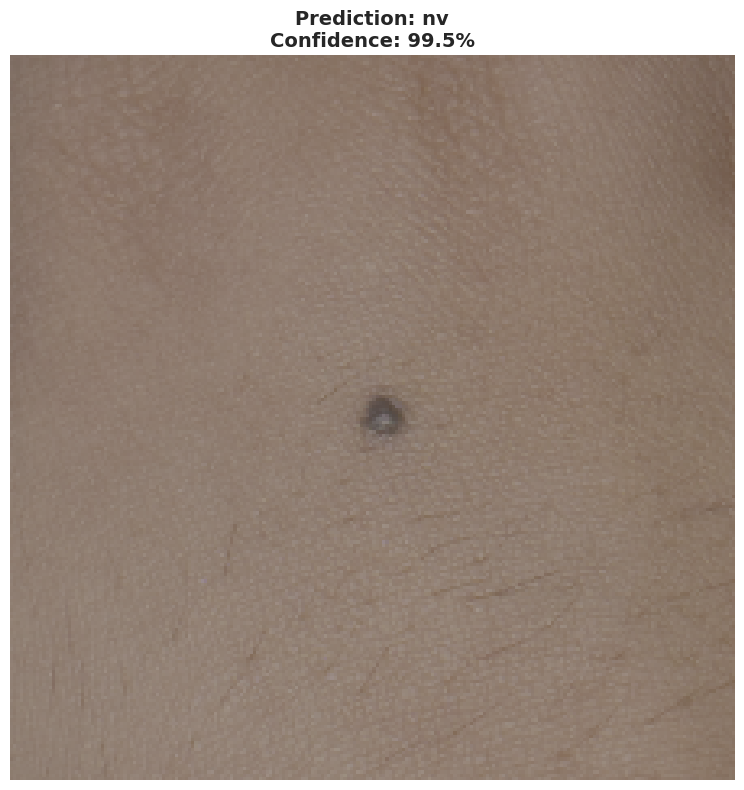



Trying MAX CONFIDENCE method:

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 99.50%)
Skin Diseases       : Warts Molluscum and other Viral Infections - 2103 (confidence: 70.29%)
DermNet             : Vascular Tumors                (confidence: 42.33%)

ENSEMBLE PREDICTIONS
Voting:            nv                             (avg confidence: 99.50%)
Weighted Average:  nv                             (weighted score: 35.72%)
Max Confidence:    nv                             (confidence: 99.50%)

FINAL PREDICTION (CONFIDENCE): nv
Confidence: 99.50%


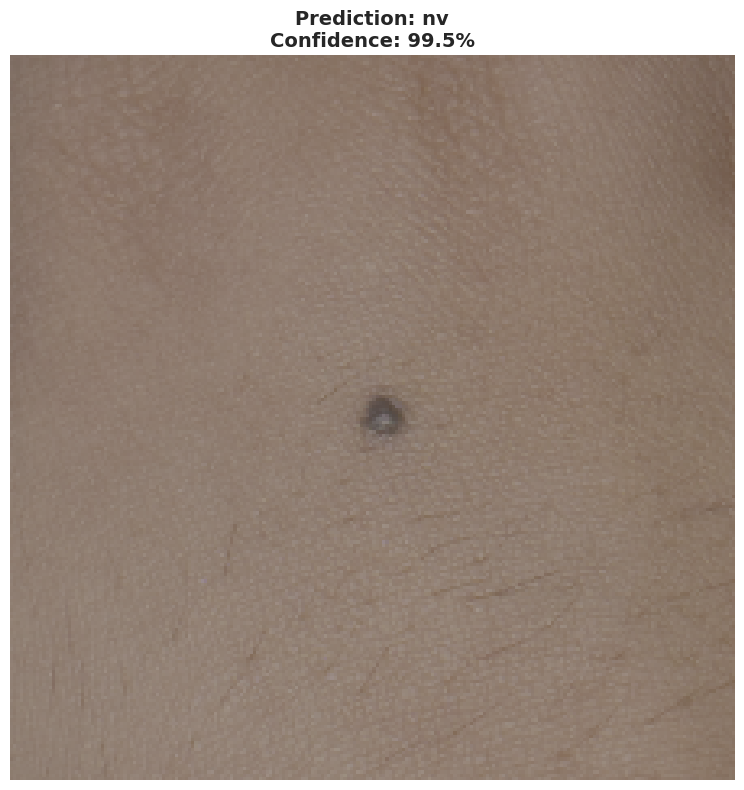

In [23]:
# Try other methods
print("\n\nTrying VOTING method:")
result_voting = predict_with_ensemble(image_path, method='voting')

print("\n\nTrying MAX CONFIDENCE method:")
result_conf = predict_with_ensemble(image_path, method='confidence')

## Batch Prediction Function

In [24]:
def predict_batch(image_paths, method='weighted'):
    """Predict multiple images"""
    results = []

    for img_path in image_paths:
        print(f"\nProcessing: {img_path}")
        result = predict_with_ensemble(img_path, method=method)
        results.append(result)

    return results

# Example usage:
# results = predict_batch(['image1.jpg', 'image2.jpg', 'image3.jpg'])

## Export Ensemble as Single Function

For deployment in your application

In [25]:
# Save ensemble configuration
ensemble_config = {
    'models': [
        {
            'name': 'HAM10000',
            'model_path': 'ham10000_final.keras',
            'classes_path': 'ham10000_classes.json',
            'accuracy': info1['test_accuracy']
        },
        {
            'name': 'Skin Diseases',
            'model_path': 'skin_diseases_final.keras',
            'classes_path': 'skin_diseases_classes.json',
            'accuracy': info2['test_accuracy']
        },
        {
            'name': 'DermNet',
            'model_path': 'dermnet_final.keras',
            'classes_path': 'dermnet_classes.json',
            'accuracy': info3['test_accuracy']
        }
    ],
    'recommended_method': 'weighted',
    'total_classes': len(all_classes)
}

with open(os.path.join(MODEL_DIR, 'ensemble_config.json'), 'w') as f:
    json.dump(ensemble_config, f, indent=2)

print("✅ Ensemble configuration saved!")
print(f"\nTo use in production:")
print("1. Load all 3 models")
print("2. Use predict_with_ensemble() function")
print("3. Recommended method: 'weighted'")

✅ Ensemble configuration saved!

To use in production:
1. Load all 3 models
2. Use predict_with_ensemble() function
3. Recommended method: 'weighted'


In [26]:
# =============================================================================
# 🎯 TEST ENSEMBLE WITH 15 RANDOM IMAGES (5 FROM EACH DATASET)
# =============================================================================
# Insert this cell AFTER "Export Ensemble as Single Function" section

import os
import random
import glob
import matplotlib.pyplot as plt
from PIL import Image

def test_ensemble_with_samples():
    """
    Test ensemble with 5 random images from each of the 3 test datasets
    Total: 15 images
    """

    print("="*90)
    print("🎲 TESTING ENSEMBLE WITH 15 RANDOM IMAGES (5 from each dataset)")
    print("="*90)

    # Define paths to test datasets
    # These should be the paths created during training (in /content/)
    dataset_paths = {
        'HAM10000': '/content/ham10000_organized/test',
        'Skin Diseases': '/content/skin_diseases_organized/test',
        'DermNet': '/content/dermnet_organized/test'
    }

    all_samples = []

    # Sample 5 images from each dataset
    for dataset_name, test_path in dataset_paths.items():

        print(f"\n📂 Sampling from {dataset_name}...")

        # Check if path exists
        if not os.path.exists(test_path):
            print(f"   ⚠️  Warning: Path not found: {test_path}")
            print(f"   This is normal if you haven't run the training notebook yet.")
            print(f"   Skipping {dataset_name}...\n")
            continue

        # Collect all images from all class folders
        all_images = []

        try:
            class_folders = [d for d in os.listdir(test_path)
                           if os.path.isdir(os.path.join(test_path, d))]

            for class_folder in class_folders:
                class_path = os.path.join(test_path, class_folder)

                # Find all image files
                images = (glob.glob(os.path.join(class_path, '*.jpg')) +
                         glob.glob(os.path.join(class_path, '*.jpeg')) +
                         glob.glob(os.path.join(class_path, '*.png')))

                all_images.extend(images)

            # Randomly sample 5 images
            if len(all_images) >= 5:
                sampled = random.sample(all_images, 5)
                print(f"   ✓ Sampled 5 images from {len(all_images)} available")
            elif len(all_images) > 0:
                sampled = all_images
                print(f"   ✓ Sampled {len(sampled)} images (all available)")
            else:
                print(f"   ⚠️  No images found")
                continue

            # Store sample info
            for img_path in sampled:
                all_samples.append({
                    'path': img_path,
                    'dataset': dataset_name,
                    'true_class': os.path.basename(os.path.dirname(img_path)),
                    'filename': os.path.basename(img_path)
                })

        except Exception as e:
            print(f"   ❌ Error sampling from {dataset_name}: {str(e)}")
            continue

    # Check if we got any samples
    if not all_samples:
        print("\n❌ ERROR: No images were sampled!")
        print("\nPossible reasons:")
        print("1. Training notebooks haven't been run yet (no organized test folders)")
        print("2. Paths are incorrect")
        print("3. Test folders are empty")
        print("\nMake sure you've run the training notebooks first!")
        return None

    print(f"\n{'='*90}")
    print(f"✅ Successfully collected {len(all_samples)} images")
    print(f"{'='*90}\n")

    # Test each image
    results = []

    for i, sample in enumerate(all_samples, 1):
        print(f"\n{'─'*90}")
        print(f"Testing Image {i}/{len(all_samples)}")
        print(f"Dataset: {sample['dataset']}")
        print(f"File: {sample['filename']}")
        print(f"True Class: {sample['true_class']}")
        print(f"{'─'*90}")

        try:
            # Make prediction using ensemble
            result = predict_with_ensemble(sample['path'], method='weighted')

            # Store results
            sample['predicted'] = result['final_prediction']
            sample['confidence'] = result['confidence']
            sample['ensemble_results'] = result['ensemble_results']

            results.append(sample)

        except Exception as e:
            print(f"❌ Error predicting: {str(e)}")
            continue

    # Print summary
    if results:
        print(f"\n\n{'='*90}")
        print("📊 RESULTS SUMMARY")
        print(f"{'='*90}\n")

        # By dataset
        for dataset_name in dataset_paths.keys():
            dataset_results = [r for r in results if r['dataset'] == dataset_name]
            if dataset_results:
                avg_conf = sum(r['confidence'] for r in dataset_results) / len(dataset_results)
                print(f"📂 {dataset_name}:")
                print(f"   Images tested: {len(dataset_results)}")
                print(f"   Average confidence: {avg_conf*100:.2f}%")
                print()

        # Overall
        overall_conf = sum(r['confidence'] for r in results) / len(results)
        print(f"🎯 OVERALL:")
        print(f"   Total images tested: {len(results)}")
        print(f"   Average confidence: {overall_conf*100:.2f}%")

        print(f"\n{'='*90}\n")

    return results


def visualize_ensemble_results(results):
    """
    Create a 3x5 grid visualization of the test results
    """

    if not results:
        print("❌ No results to visualize!")
        return

    print("📸 Creating visualization...\n")

    # Pad results to 15 if fewer
    display_results = results + [None] * (15 - len(results))
    display_results = display_results[:15]  # Cap at 15

    # Create 3x5 grid
    fig, axes = plt.subplots(3, 5, figsize=(25, 15))
    axes = axes.flatten()

    for i, result in enumerate(display_results):
        ax = axes[i]

        if result is None:
            ax.axis('off')
            continue

        try:
            # Load and display image
            img = Image.open(result['path'])
            ax.imshow(img)

            # Create title
            title_lines = [
                f"Dataset: {result['dataset']}",
                f"True: {result['true_class'][:35]}",
                f"Pred: {result['predicted'][:35]}",
                f"Confidence: {result['confidence']*100:.1f}%"
            ]
            title = '\n'.join(title_lines)

            # Check if prediction seems correct (fuzzy match)
            true_words = set(result['true_class'].lower().split())
            pred_words = set(result['predicted'].lower().split())

            # Simple overlap check
            overlap = true_words & pred_words
            color = 'green' if len(overlap) > 0 else 'orange'

            ax.set_title(title, fontsize=9, color=color, fontweight='bold', pad=10)
            ax.axis('off')

        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\nimage {i+1}',
                   ha='center', va='center', fontsize=10)
            ax.axis('off')

    plt.suptitle('Ensemble Testing Results: 15 Random Images from 3 Datasets',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    print("✅ Visualization complete!\n")


# =============================================================================
# 🚀 RUN THE TEST
# =============================================================================

print("\n" + "="*90)
print("🚀 STARTING ENSEMBLE TEST WITH RANDOM SAMPLES")
print("="*90 + "\n")

# Step 1: Sample and test images
results = test_ensemble_with_samples()

# Step 2: Visualize results
if results:
    print("\n" + "="*90)
    print("📊 GENERATING VISUALIZATION")
    print("="*90 + "\n")
    visualize_ensemble_results(results)

    print("\n" + "="*90)
    print("✅ ENSEMBLE TEST COMPLETE!")
    print("="*90)
    print(f"\nTested {len(results)} images across 3 datasets")
    print("Check the visualization above to see predictions!")
    print("="*90 + "\n")
else:
    print("\n" + "="*90)
    print("❌ TEST FAILED")
    print("="*90)
    print("\n⚠️  Make sure you have run the training notebooks first!")
    print("The test datasets need to exist at:")
    print("  • /content/ham10000_organized/test")
    print("  • /content/skin_diseases_organized/test")
    print("  • /content/dermnet_organized/test")
    print("\nThese folders are created automatically when you run")
    print("the training notebooks (1_train_ham10000.ipynb, etc.)")
    print("="*90 + "\n")


🚀 STARTING ENSEMBLE TEST WITH RANDOM SAMPLES

🎲 TESTING ENSEMBLE WITH 15 RANDOM IMAGES (5 from each dataset)

📂 Sampling from HAM10000...
   ⚠️  Warning: Path not found: /content/ham10000_organized/test
   This is normal if you haven't run the training notebook yet.
   Skipping HAM10000...


📂 Sampling from Skin Diseases...
   ⚠️  Warning: Path not found: /content/skin_diseases_organized/test
   This is normal if you haven't run the training notebook yet.
   Skipping Skin Diseases...


📂 Sampling from DermNet...
   ⚠️  Warning: Path not found: /content/dermnet_organized/test
   This is normal if you haven't run the training notebook yet.
   Skipping DermNet...


❌ ERROR: No images were sampled!

Possible reasons:
1. Training notebooks haven't been run yet (no organized test folders)
2. Paths are incorrect
3. Test folders are empty

Make sure you've run the training notebooks first!

❌ TEST FAILED

⚠️  Make sure you have run the training notebooks first!
The test datasets need to exist

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



🚀 STARTING ENSEMBLE TEST

Step 1: Setting up test data...
📥 DOWNLOADING TEST DATA FROM DATASETS

This will take a few minutes (one-time setup)...

1️⃣  Downloading HAM10000...
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
   ✅ HAM10000 test data ready

2️⃣  Downloading Skin Diseases...
Using Colab cache for faster access to the 'skin-diseases-image-dataset' dataset.
   ✅ Skin Diseases test data ready

3️⃣  Downloading DermNet...


100%|██████████| 1.72G/1.72G [01:21<00:00, 22.8MB/s]

Extracting files...


   ✅ DermNet test data ready

✅ Test data setup complete! 3 datasets ready.


Step 2: Testing ensemble...
🎲 SAMPLING 15 RANDOM IMAGES (5 from each dataset)

📂 Sampling from HAM10000...
   ✓ Sampled 5 images

📂 Sampling from Skin Diseases...
   ✓ Sampled 5 images

📂 Sampling from DermNet...
   ✓ Sampled 0 images

✅ Total: 10 images


──────────────────────────────────────────────────────────────────────────────────────────
Image 1/10: ISIC_0027282.jpg
Dataset: HAM10000 | True Class: mel
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 79.97%)
Skin Diseases       : Melanocytic Nevi (NV) - 7970   (confidence: 98.92%)
DermNet             : Vascular Tumors                (confidence: 68.95%)

ENSEMBLE PREDICTIONS
Voting:            Melanocytic Nevi (NV) - 7970   (avg confidence: 98.92%)
Weighted Average:  Melanocytic Nevi (NV) - 7970   (weighted score: 33

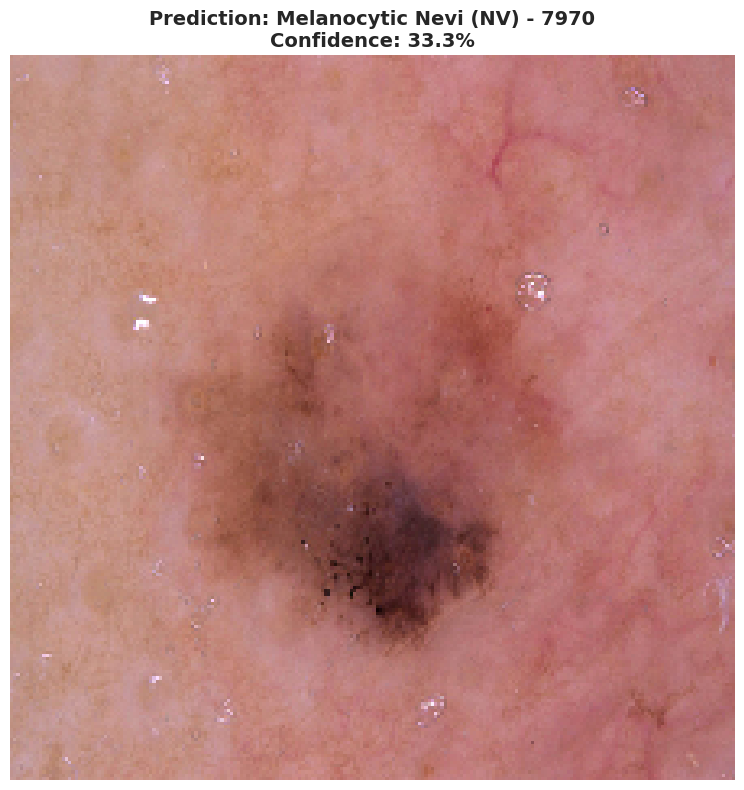


──────────────────────────────────────────────────────────────────────────────────────────
Image 2/10: ISIC_0029041.jpg
Dataset: HAM10000 | True Class: akiec
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : akiec                          (confidence: 49.37%)
Skin Diseases       : Basal Cell Carcinoma (BCC) 3323 (confidence: 74.96%)
DermNet             : Vascular Tumors                (confidence: 94.48%)

ENSEMBLE PREDICTIONS
Voting:            Vascular Tumors                (avg confidence: 94.48%)
Weighted Average:  Vascular Tumors                (weighted score: 28.72%)
Max Confidence:    Vascular Tumors                (confidence: 94.48%)

FINAL PREDICTION (WEIGHTED): Vascular Tumors
Confidence: 28.72%


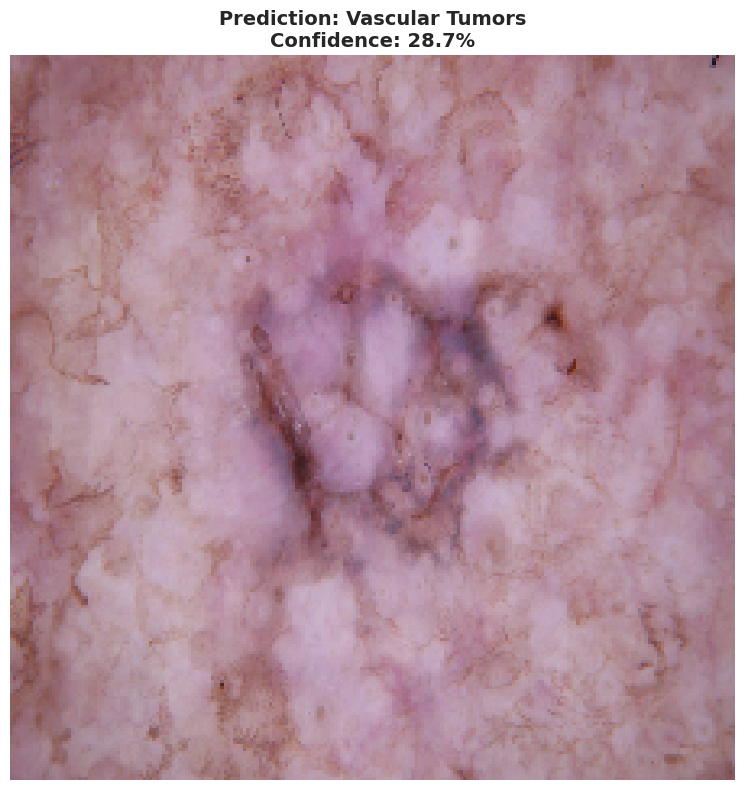


──────────────────────────────────────────────────────────────────────────────────────────
Image 3/10: ISIC_0029029.jpg
Dataset: HAM10000 | True Class: bkl
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bkl                            (confidence: 95.50%)
Skin Diseases       : Benign Keratosis-like Lesions (BKL) 2624 (confidence: 96.81%)
DermNet             : Scabies Lyme Disease and other Infestations and Bites (confidence: 49.24%)

ENSEMBLE PREDICTIONS
Voting:            Benign Keratosis-like Lesions (BKL) 2624 (avg confidence: 96.81%)
Weighted Average:  bkl                            (weighted score: 34.28%)
Max Confidence:    Benign Keratosis-like Lesions (BKL) 2624 (confidence: 96.81%)

FINAL PREDICTION (WEIGHTED): bkl
Confidence: 34.28%


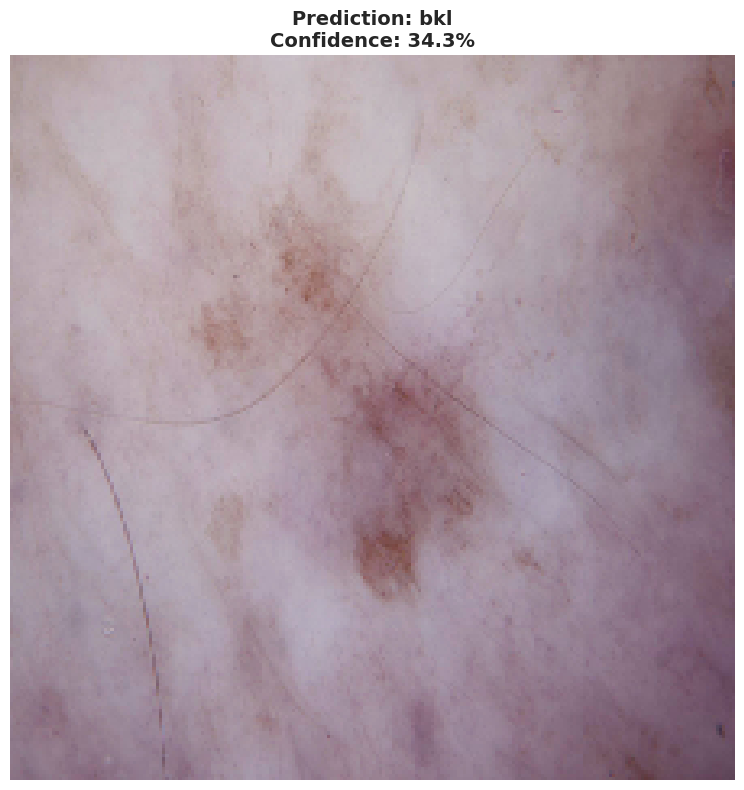


──────────────────────────────────────────────────────────────────────────────────────────
Image 4/10: ISIC_0033979.jpg
Dataset: HAM10000 | True Class: bcc
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bcc                            (confidence: 98.04%)
Skin Diseases       : Basal Cell Carcinoma (BCC) 3323 (confidence: 99.73%)
DermNet             : Vascular Tumors                (confidence: 28.97%)

ENSEMBLE PREDICTIONS
Voting:            Basal Cell Carcinoma (BCC) 3323 (avg confidence: 99.73%)
Weighted Average:  bcc                            (weighted score: 35.19%)
Max Confidence:    Basal Cell Carcinoma (BCC) 3323 (confidence: 99.73%)

FINAL PREDICTION (WEIGHTED): bcc
Confidence: 35.19%


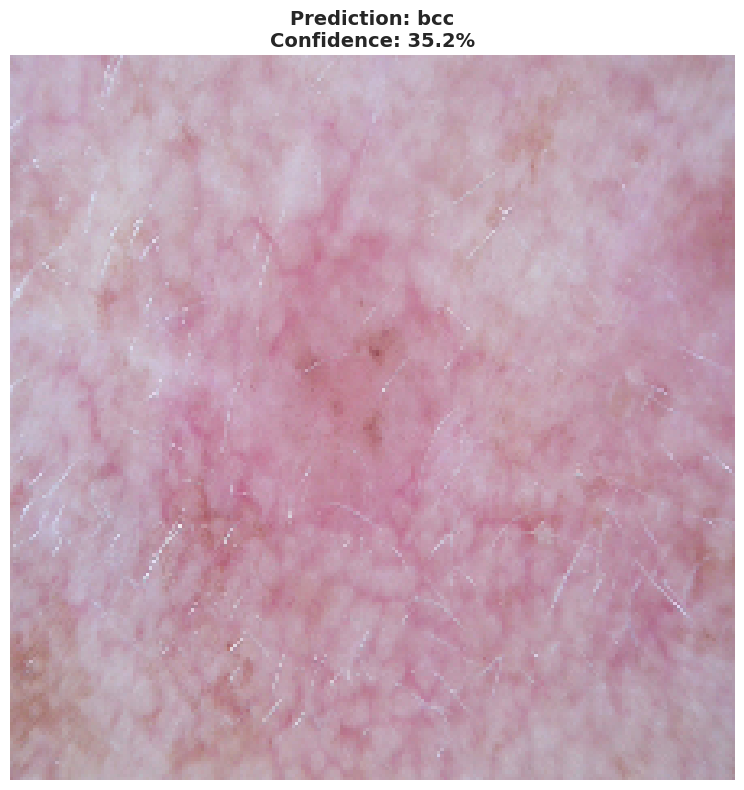


──────────────────────────────────────────────────────────────────────────────────────────
Image 5/10: ISIC_0030644.jpg
Dataset: HAM10000 | True Class: bcc
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bcc                            (confidence: 56.16%)
Skin Diseases       : Basal Cell Carcinoma (BCC) 3323 (confidence: 90.24%)
DermNet             : Vascular Tumors                (confidence: 38.33%)

ENSEMBLE PREDICTIONS
Voting:            Basal Cell Carcinoma (BCC) 3323 (avg confidence: 90.24%)
Weighted Average:  Basal Cell Carcinoma (BCC) 3323 (weighted score: 30.42%)
Max Confidence:    Basal Cell Carcinoma (BCC) 3323 (confidence: 90.24%)

FINAL PREDICTION (WEIGHTED): Basal Cell Carcinoma (BCC) 3323
Confidence: 30.42%


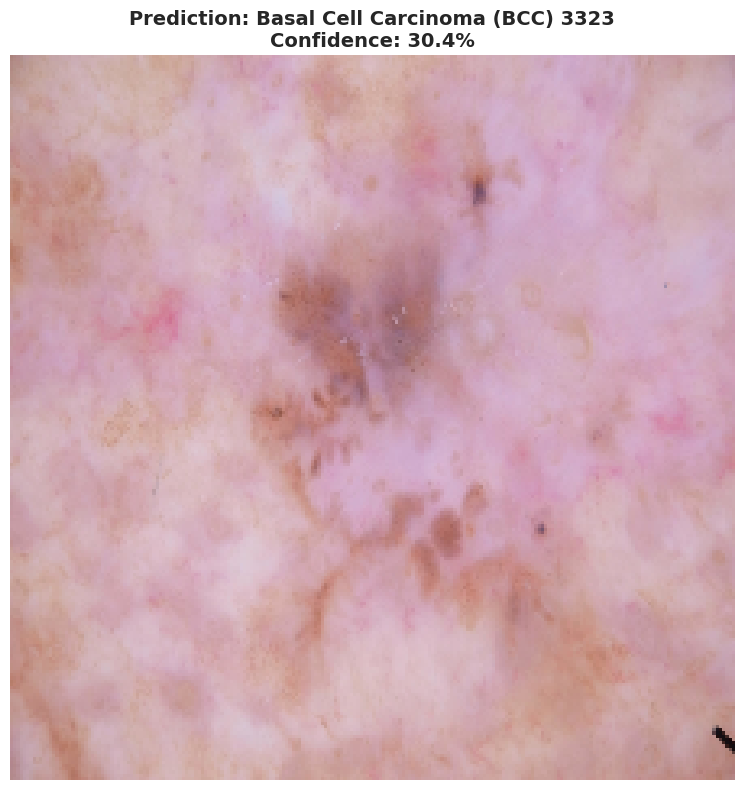


──────────────────────────────────────────────────────────────────────────────────────────
Image 6/10: t-Lichen-Planus-Oral-47.jpg
Dataset: Skin Diseases | True Class: Psoriasis pictures Lichen Planus and related diseases - 2k
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : df                             (confidence: 49.42%)
Skin Diseases       : Warts Molluscum and other Viral Infections - 2103 (confidence: 40.55%)
DermNet             : Acne and Rosacea Photos        (confidence: 28.53%)

ENSEMBLE PREDICTIONS
Voting:            df                             (avg confidence: 49.42%)
Weighted Average:  df                             (weighted score: 17.74%)
Max Confidence:    df                             (confidence: 49.42%)

FINAL PREDICTION (WEIGHTED): df
Confidence: 17.74%


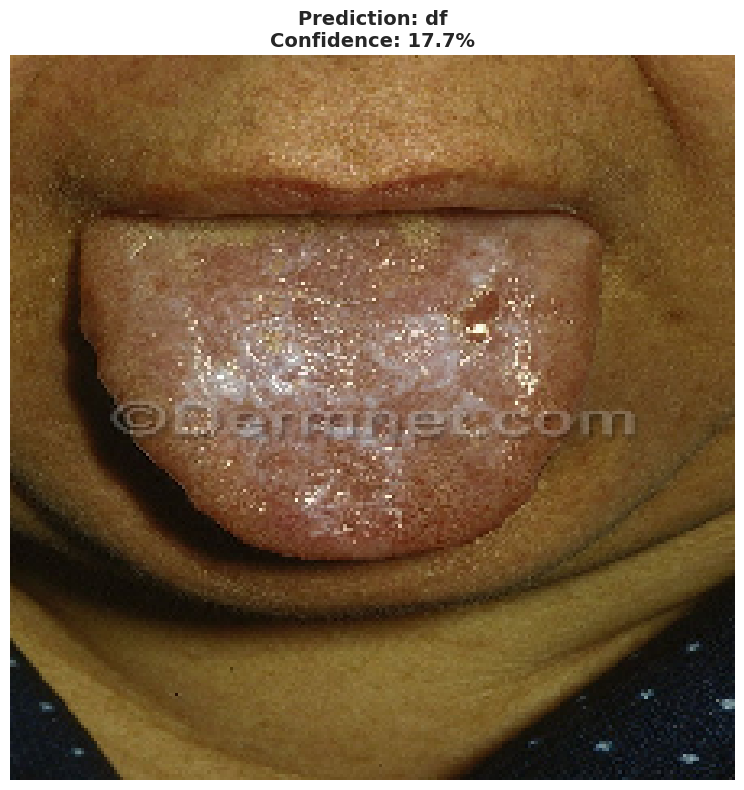


──────────────────────────────────────────────────────────────────────────────────────────
Image 7/10: 6_315.jpg
Dataset: Skin Diseases | True Class: Atopic Dermatitis - 1.25k
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : bkl                            (confidence: 85.39%)
Skin Diseases       : Atopic Dermatitis - 1.25k      (confidence: 36.22%)
DermNet             : Nail Fungus and other Nail Disease (confidence: 39.92%)

ENSEMBLE PREDICTIONS
Voting:            bkl                            (avg confidence: 85.39%)
Weighted Average:  bkl                            (weighted score: 30.65%)
Max Confidence:    bkl                            (confidence: 85.39%)

FINAL PREDICTION (WEIGHTED): bkl
Confidence: 30.65%


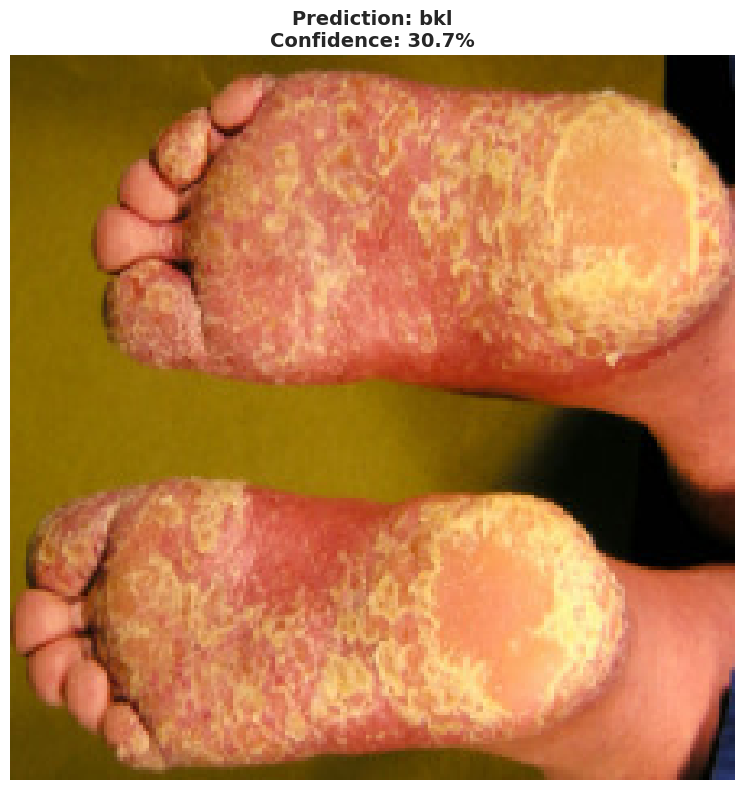


──────────────────────────────────────────────────────────────────────────────────────────
Image 8/10: ISIC_0000221.jpg
Dataset: Skin Diseases | True Class: Melanocytic Nevi (NV) - 7970
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 76.36%)
Skin Diseases       : Melanocytic Nevi (NV) - 7970   (confidence: 88.27%)
DermNet             : Light Diseases and Disorders of Pigmentation (confidence: 98.31%)

ENSEMBLE PREDICTIONS
Voting:            Light Diseases and Disorders of Pigmentation (avg confidence: 98.31%)
Weighted Average:  Light Diseases and Disorders of Pigmentation (weighted score: 29.88%)
Max Confidence:    Light Diseases and Disorders of Pigmentation (confidence: 98.31%)

FINAL PREDICTION (WEIGHTED): Light Diseases and Disorders of Pigmentation
Confidence: 29.88%


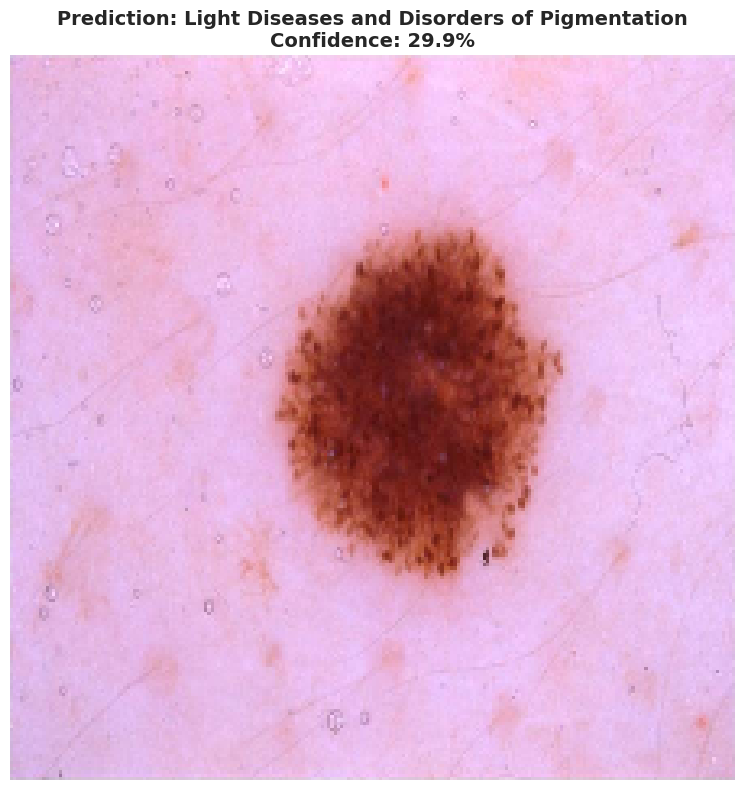


──────────────────────────────────────────────────────────────────────────────────────────
Image 9/10: ISIC_0032052.jpg
Dataset: Skin Diseases | True Class: Melanocytic Nevi (NV) - 7970
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 96.73%)
Skin Diseases       : Melanocytic Nevi (NV) - 7970   (confidence: 94.68%)
DermNet             : Light Diseases and Disorders of Pigmentation (confidence: 38.52%)

ENSEMBLE PREDICTIONS
Voting:            nv                             (avg confidence: 96.73%)
Weighted Average:  nv                             (weighted score: 34.72%)
Max Confidence:    nv                             (confidence: 96.73%)

FINAL PREDICTION (WEIGHTED): nv
Confidence: 34.72%


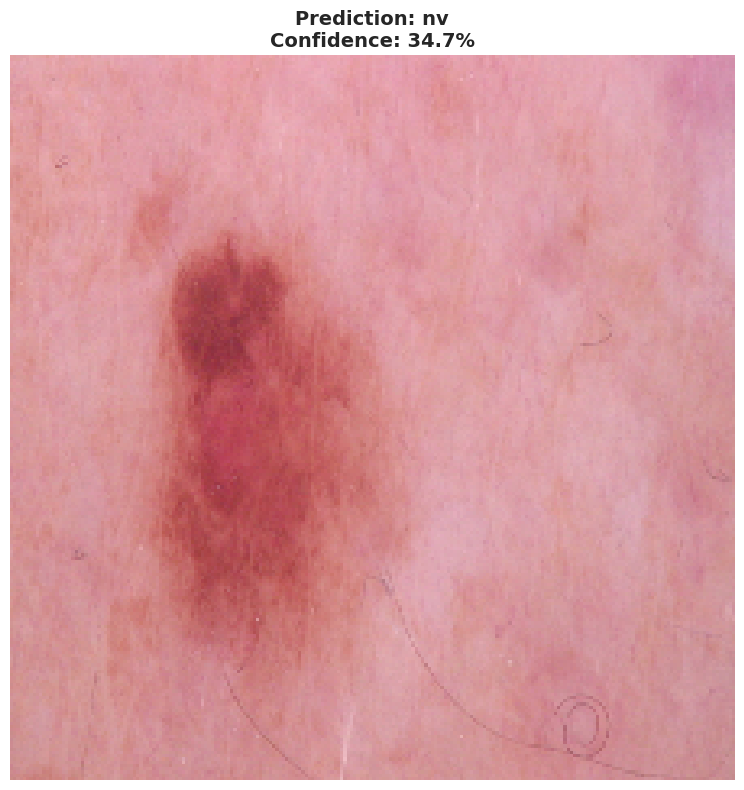


──────────────────────────────────────────────────────────────────────────────────────────
Image 10/10: t-dermatofibroma-66.jpg
Dataset: Skin Diseases | True Class: Seborrheic Keratoses and other Benign Tumors - 1.8k
──────────────────────────────────────────────────────────────────────────────────────────

INDIVIDUAL MODEL PREDICTIONS
HAM10000            : nv                             (confidence: 25.56%)
Skin Diseases       : Seborrheic Keratoses and other Benign Tumors - 1.8k (confidence: 95.49%)
DermNet             : Scabies Lyme Disease and other Infestations and Bites (confidence: 89.31%)

ENSEMBLE PREDICTIONS
Voting:            Seborrheic Keratoses and other Benign Tumors - 1.8k (avg confidence: 95.49%)
Weighted Average:  Seborrheic Keratoses and other Benign Tumors - 1.8k (weighted score: 32.19%)
Max Confidence:    Seborrheic Keratoses and other Benign Tumors - 1.8k (confidence: 95.49%)

FINAL PREDICTION (WEIGHTED): Seborrheic Keratoses and other Benign Tumors - 1.8k
Confide

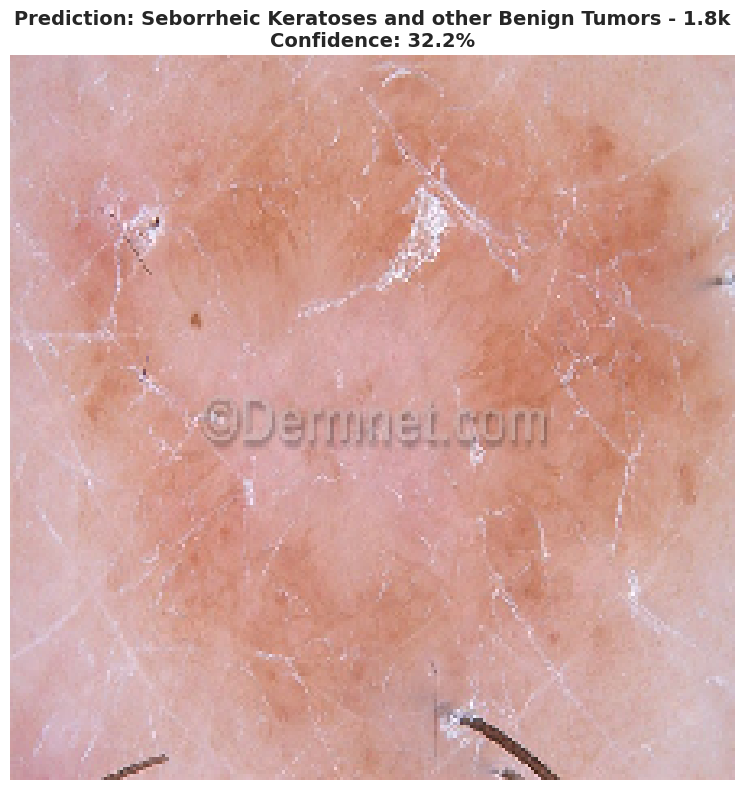



📊 RESULTS SUMMARY

📂 HAM10000: 5 images, Avg confidence: 32.39%
📂 Skin Diseases: 5 images, Avg confidence: 29.04%

🎯 Overall: 10 images, Avg confidence: 30.71%



Step 3: Visualizing results...
📸 Creating visualization...



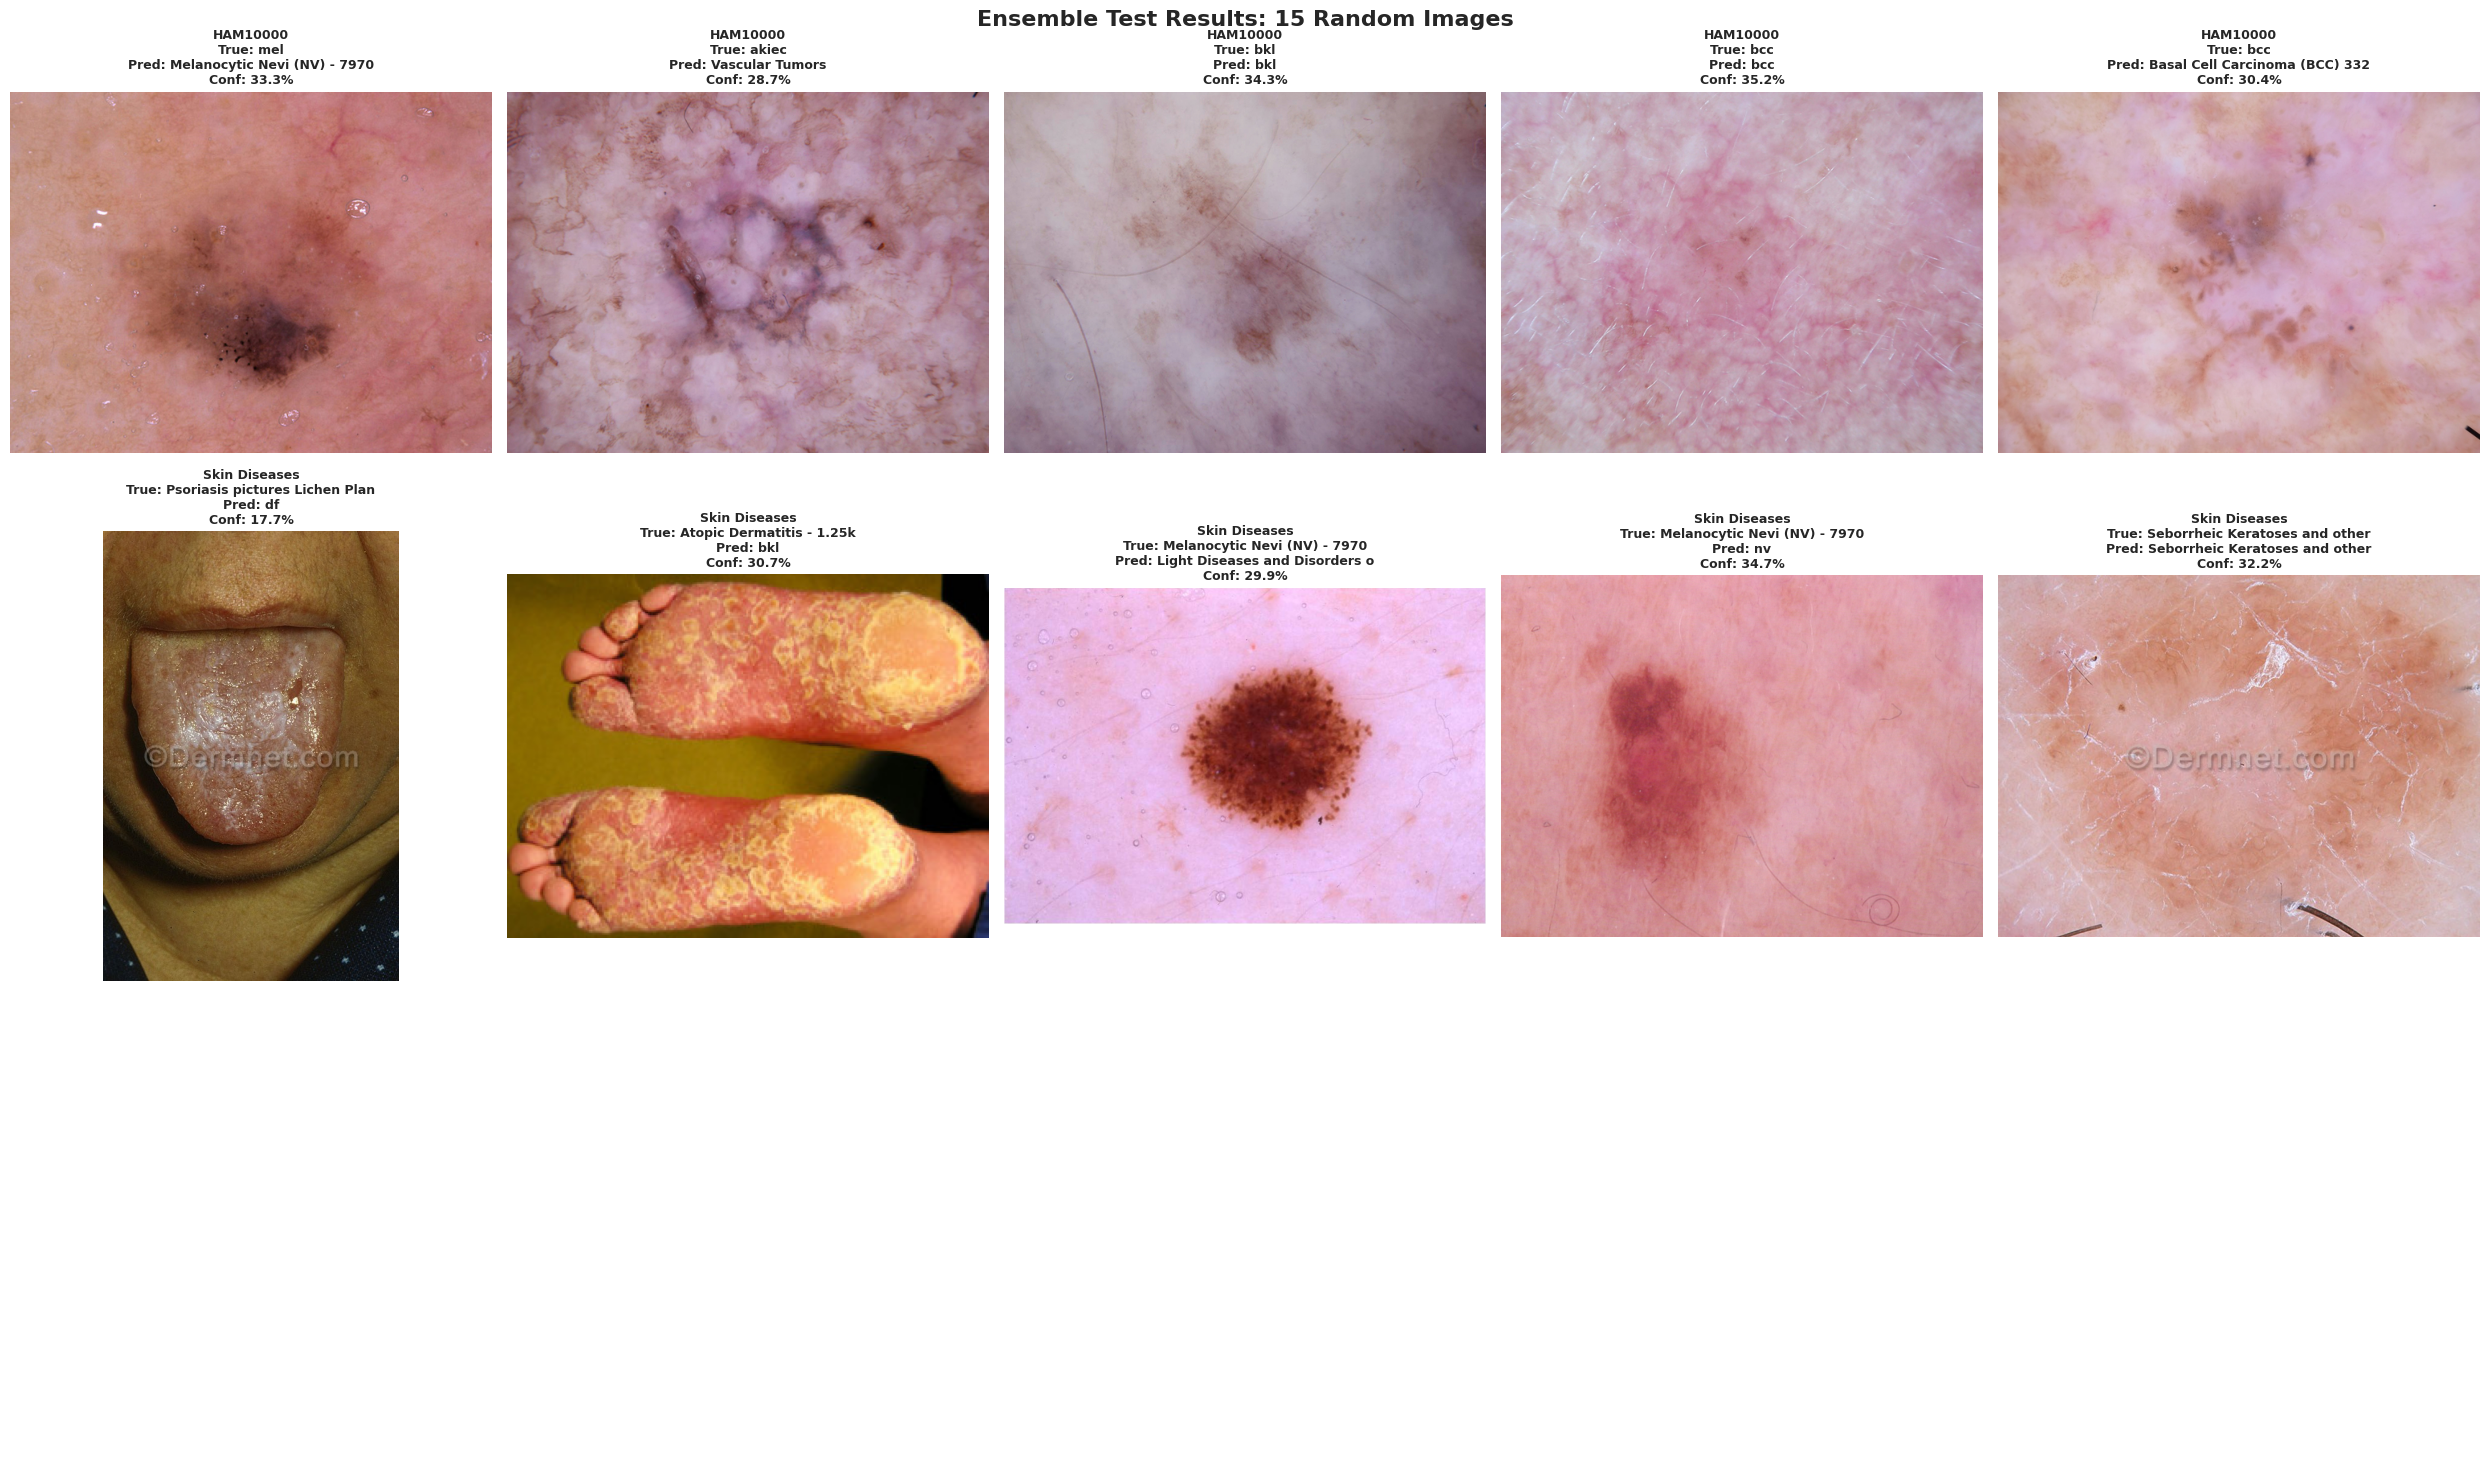


✅ ENSEMBLE TEST COMPLETE!
Tested 10 images from 3 datasets



In [28]:
# =============================================================================
# 🎯 TEST ENSEMBLE WITH 15 RANDOM IMAGES
# =============================================================================
# This version downloads test data directly in the ensemble notebook

import os
import random
import glob
import shutil
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import kagglehub

def setup_test_data():
    """
    Download and organize test data from all 3 datasets
    Only creates test folders (much faster than full training setup)
    """

    print("="*90)
    print("📥 DOWNLOADING TEST DATA FROM DATASETS")
    print("="*90)
    print("\nThis will take a few minutes (one-time setup)...\n")

    test_dirs = {}

    # 1. Setup HAM10000
    try:
        print("1️⃣  Downloading HAM10000...")
        HAM_PATH = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

        # Find metadata and images
        metadata_files = glob.glob(os.path.join(HAM_PATH, '**/*.csv'), recursive=True)
        image_dirs = glob.glob(os.path.join(HAM_PATH, '**/*images*'), recursive=True)

        metadata_file = [f for f in metadata_files if 'metadata' in f.lower()][0]
        import pandas as pd
        df = pd.read_csv(metadata_file)

        # Get all images
        all_images = []
        for img_dir in image_dirs:
            if os.path.isdir(img_dir):
                all_images.extend(glob.glob(os.path.join(img_dir, '*.jpg')))

        image_map = {os.path.basename(img).replace('.jpg', ''): img for img in all_images}

        # Create test directory
        ham_test_dir = '/ham10000_test'
        os.makedirs(ham_test_dir, exist_ok=True)

        # Create class folders and copy images (only 20% for test)
        classes = df['dx'].unique()
        for cls in classes:
            os.makedirs(os.path.join(ham_test_dir, cls), exist_ok=True)

        for cls in classes:
            class_df = df[df['dx'] == cls]
            # Take only 20% for test (faster)
            _, test_ids = train_test_split(class_df['image_id'].values, test_size=0.2, random_state=42)

            for img_id in test_ids[:10]:  # Max 10 per class to save time
                if img_id in image_map:
                    src = image_map[img_id]
                    dst = os.path.join(ham_test_dir, cls, f"{img_id}.jpg")
                    shutil.copy2(src, dst)

        test_dirs['HAM10000'] = ham_test_dir
        print("   ✅ HAM10000 test data ready\n")

    except Exception as e:
        print(f"   ⚠️  HAM10000 setup failed: {str(e)}\n")

    # 2. Setup Skin Diseases
    try:
        print("2️⃣  Downloading Skin Diseases...")
        SKIN_PATH = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")

        IMG_CLASSES_PATH = os.path.join(SKIN_PATH, 'IMG_CLASSES')

        skin_test_dir = '/skin_diseases_test'
        os.makedirs(skin_test_dir, exist_ok=True)

        # Copy a subset of images from each class
        for cls_folder in os.listdir(IMG_CLASSES_PATH):
            cls_path = os.path.join(IMG_CLASSES_PATH, cls_folder)
            if not os.path.isdir(cls_path):
                continue

            clean_name = cls_folder.split('. ', 1)[-1] if '. ' in cls_folder else cls_folder
            test_cls_path = os.path.join(skin_test_dir, clean_name)
            os.makedirs(test_cls_path, exist_ok=True)

            # Get images
            images = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]

            # Take 20% for test, max 10 images per class
            _, test_imgs = train_test_split(images, test_size=0.2, random_state=42)
            test_imgs = test_imgs[:10]

            for img in test_imgs:
                shutil.copy2(os.path.join(cls_path, img), os.path.join(test_cls_path, img))

        test_dirs['Skin Diseases'] = skin_test_dir
        print("   ✅ Skin Diseases test data ready\n")

    except Exception as e:
        print(f"   ⚠️  Skin Diseases setup failed: {str(e)}\n")

    # 3. Setup DermNet
    try:
        print("3️⃣  Downloading DermNet...")
        DERMNET_PATH = kagglehub.dataset_download("shubhamgoel27/dermnet")

        # Find image folders
        possible_paths = [DERMNET_PATH, os.path.join(DERMNET_PATH, 'versions', '1')]
        DERMNET_IMG_PATH = DERMNET_PATH

        for test_path in possible_paths:
            if os.path.exists(test_path):
                subdirs = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]
                if subdirs:
                    first_dir = os.path.join(test_path, subdirs[0])
                    files = os.listdir(first_dir)
                    if any(f.lower().endswith(('.jpg', '.png')) for f in files):
                        DERMNET_IMG_PATH = test_path
                        break

        derm_test_dir = '/dermnet_test'
        os.makedirs(derm_test_dir, exist_ok=True)

        # Copy subset of images
        for cls_folder in os.listdir(DERMNET_IMG_PATH):
            cls_path = os.path.join(DERMNET_IMG_PATH, cls_folder)
            if not os.path.isdir(cls_path):
                continue

            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png'))]
            if len(images) == 0:
                continue

            test_cls_path = os.path.join(derm_test_dir, cls_folder)
            os.makedirs(test_cls_path, exist_ok=True)

            # Take 20% for test, max 10 images per class
            if len(images) > 5:
                _, test_imgs = train_test_split(images, test_size=0.2, random_state=42)
                test_imgs = test_imgs[:10]
            else:
                test_imgs = images

            for img in test_imgs:
                shutil.copy2(os.path.join(cls_path, img), os.path.join(test_cls_path, img))

        test_dirs['DermNet'] = derm_test_dir
        print("   ✅ DermNet test data ready\n")

    except Exception as e:
        print(f"   ⚠️  DermNet setup failed: {str(e)}\n")

    print("="*90)
    print(f"✅ Test data setup complete! {len(test_dirs)} datasets ready.")
    print("="*90 + "\n")

    return test_dirs


def test_ensemble_with_samples(test_dirs):
    """
    Test ensemble with 5 random images from each dataset
    """

    print("="*90)
    print("🎲 SAMPLING 15 RANDOM IMAGES (5 from each dataset)")
    print("="*90)

    all_samples = []

    # Sample from each dataset
    for dataset_name, test_path in test_dirs.items():
        print(f"\n📂 Sampling from {dataset_name}...")

        # Collect all images
        all_images = []
        class_folders = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]

        for class_folder in class_folders:
            class_path = os.path.join(test_path, class_folder)
            images = glob.glob(os.path.join(class_path, '*.jpg')) + \
                    glob.glob(os.path.join(class_path, '*.jpeg')) + \
                    glob.glob(os.path.join(class_path, '*.png'))
            all_images.extend(images)

        # Sample 5 random images
        if len(all_images) >= 5:
            sampled = random.sample(all_images, 5)
        else:
            sampled = all_images

        print(f"   ✓ Sampled {len(sampled)} images")

        for img_path in sampled:
            all_samples.append({
                'path': img_path,
                'dataset': dataset_name,
                'true_class': os.path.basename(os.path.dirname(img_path)),
                'filename': os.path.basename(img_path)
            })

    print(f"\n{'='*90}")
    print(f"✅ Total: {len(all_samples)} images")
    print(f"{'='*90}\n")

    # Test each image
    results = []

    for i, sample in enumerate(all_samples, 1):
        print(f"\n{'─'*90}")
        print(f"Image {i}/{len(all_samples)}: {sample['filename']}")
        print(f"Dataset: {sample['dataset']} | True Class: {sample['true_class']}")
        print(f"{'─'*90}")

        try:
            result = predict_with_ensemble(sample['path'], method='weighted')

            sample['predicted'] = result['final_prediction']
            sample['confidence'] = result['confidence']
            results.append(sample)

        except Exception as e:
            print(f"❌ Error: {str(e)}")

    # Summary
    if results:
        print(f"\n\n{'='*90}")
        print("📊 RESULTS SUMMARY")
        print(f"{'='*90}\n")

        for dataset_name in test_dirs.keys():
            dataset_results = [r for r in results if r['dataset'] == dataset_name]
            if dataset_results:
                avg_conf = sum(r['confidence'] for r in dataset_results) / len(dataset_results)
                print(f"📂 {dataset_name}: {len(dataset_results)} images, Avg confidence: {avg_conf*100:.2f}%")

        overall_conf = sum(r['confidence'] for r in results) / len(results)
        print(f"\n🎯 Overall: {len(results)} images, Avg confidence: {overall_conf*100:.2f}%")
        print(f"\n{'='*90}\n")

    return results


def visualize_results(results):
    """Visualize in 3x5 grid"""

    if not results:
        return

    print("📸 Creating visualization...\n")

    fig, axes = plt.subplots(3, 5, figsize=(25, 15))
    axes = axes.flatten()

    for i in range(15):
        ax = axes[i]

        if i < len(results):
            result = results[i]
            try:
                img = Image.open(result['path'])
                ax.imshow(img)

                title = f"{result['dataset']}\nTrue: {result['true_class'][:30]}\n"
                title += f"Pred: {result['predicted'][:30]}\nConf: {result['confidence']*100:.1f}%"

                ax.set_title(title, fontsize=9, fontweight='bold')
                ax.axis('off')
            except:
                ax.axis('off')
        else:
            ax.axis('off')

    plt.suptitle('Ensemble Test Results: 15 Random Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# =============================================================================
# 🚀 RUN THE COMPLETE TEST
# =============================================================================

print("\n🚀 STARTING ENSEMBLE TEST\n")

# Step 1: Setup test data (downloads and organizes)
print("Step 1: Setting up test data...")
test_dirs = setup_test_data()

if test_dirs:
    # Step 2: Test ensemble
    print("\nStep 2: Testing ensemble...")
    results = test_ensemble_with_samples(test_dirs)

    # Step 3: Visualize
    if results:
        print("\nStep 3: Visualizing results...")
        visualize_results(results)

        print(f"\n{'='*90}")
        print("✅ ENSEMBLE TEST COMPLETE!")
        print(f"Tested {len(results)} images from {len(test_dirs)} datasets")
        print(f"{'='*90}\n")
else:
    print("\n❌ Could not setup test data. Check your internet connection.")

In [33]:
# Re-export models in portable H5 format
import tensorflow as tf

MODEL_DIR = '/content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models'

model_paths = [
    (f'{MODEL_DIR}/ham10000_best.keras', f'{MODEL_DIR}/ham10000_model.h5'),
    (f'{MODEL_DIR}/skin_diseases_best.keras', f'{MODEL_DIR}/skin_diseases_model.h5'),
    (f'{MODEL_DIR}/dermnet_best.keras', f'{MODEL_DIR}/dermnet_model.h5'),
]

for keras_path, h5_path in model_paths:
    print(f"Converting {keras_path} → {h5_path}")
    model = tf.keras.models.load_model(keras_path, compile=False)
    model.save(h5_path)
    print(f"  ✅ Saved")

print("\nDone! Download the .h5 files and update ensemble_config.json to use them.")

Converting /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models/ham10000_best.keras → /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models/ham10000_model.h5


  ✅ Saved
Converting /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models/skin_diseases_best.keras → /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models/skin_diseases_model.h5


  ✅ Saved
Converting /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models/dermnet_best.keras → /content/drive/MyDrive/CMPE295 Project/ML/Ensemble/Models/dermnet_model.h5


  ✅ Saved

Done! Download the .h5 files and update ensemble_config.json to use them.


## Summary

**What This Notebook Does:**
1. Loads all 3 trained models from Google Drive
2. Makes predictions with each model individually
3. Combines predictions using 3 ensemble methods:
   - **Voting**: Majority vote wins
   - **Weighted Average**: Weight by model accuracy (RECOMMENDED)
   - **Max Confidence**: Use most confident prediction

**Benefits:**
- ✅ Better accuracy than any single model
- ✅ More robust predictions
- ✅ Handles different image types (dermatoscopic vs clinical)
- ✅ Can work even if one model fails

**For Your Application:**
- Use the `predict_with_ensemble()` function
- Method: 'weighted' (best performance)
- Load models once at startup
- Keep models in Google Drive or download to your server